******Car-Dheko_Used_Car_Price_Prediction******

There are 6 files of cities data

****Data Processing****

**a)	Import and concatenate:**

i)	Import all city’s dataset which is in unstructured format.

ii)	Convert it into a  structured format.

iii)Added a new column named ‘City’ and assign values for all rows with the name of the respective city.

iv)	Concatenate all datasets and make it as a single dataset.

**Banglore**

Perfectly Done unstructured to structured Banglore cars

In [30]:
import os
import pandas as pd
import ast
from collections import defaultdict

input_folder = "csv_files"
output_file = os.path.join(input_folder, "structured_cars_data.csv")

city_map = {
    "bangalore_cars.csv": "BANGALORE",
    "chennai_cars.csv": "CHENNAI",
    "delhi_cars.csv": "DELHI",
    "hyderabad_cars.csv": "HYDERABAD",
    "jaipur_cars.csv": "JAIPUR",
    "kolkata_cars.csv": "KOLKATA"
}

def parse_dict_column(column):
    return column.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

def flatten_overview(overview_data):
    if isinstance(overview_data, dict):
        return {item['key']: item['value'] for item in overview_data.get("top", []) if isinstance(item, dict)}
    return {}

def flatten_feature(data):
    features = []
    if isinstance(data, dict):
        top = data.get("top", [])
        features.extend(f.get("value") for f in top if isinstance(f, dict))
        for section in data.get("data", []):
            if isinstance(section, dict):
                for item in section.get("list", []):
                    if isinstance(item, dict):
                        val = item.get("value")
                        if val:
                            features.append(val)
    return {'Feature_' + str(i): v for i, v in enumerate(features)}

def flatten_specs(data):
    specs = {}
    if isinstance(data, dict):
        for item in data.get("top", []):
            if isinstance(item, dict):
                k = item.get("key")
                v = item.get("value")
                if k and v:
                    specs[k] = v
        for section in data.get("data", []):
            if isinstance(section, dict):
                for item in section.get("list", []):
                    if isinstance(item, dict):
                        k = item.get("key")
                        v = item.get("value")
                        if k and v:
                            specs[k] = v
    return specs

def deduplicate_columns(columns):
    seen = defaultdict(int)
    new_columns = []
    for col in columns:
        if seen[col] == 0:
            new_columns.append(col)
        else:
            new_columns.append(f"{col}.{seen[col]}")
        seen[col] += 1
    return new_columns

dfs_combined = []

for file_name in os.listdir(input_folder):
    if file_name in city_map:
        file_path = os.path.join(input_folder, file_name)
        print(f"📥 Processing: {file_path}")
        
        try:
            df = pd.read_csv(file_path)

            for col in ["new_car_detail", "new_car_overview", "new_car_feature", "new_car_specs"]:
                if col in df.columns:
                    df[col] = parse_dict_column(df[col])

            df_overview = pd.DataFrame(df["new_car_overview"].apply(flatten_overview).tolist()) if "new_car_overview" in df.columns else pd.DataFrame()
            df_detail = pd.json_normalize(df["new_car_detail"]) if "new_car_detail" in df.columns else pd.DataFrame()
            df_feature = pd.DataFrame(df["new_car_feature"].apply(flatten_feature).tolist()) if "new_car_feature" in df.columns else pd.DataFrame()
            df_specs = pd.DataFrame(df["new_car_specs"].apply(flatten_specs).tolist()) if "new_car_specs" in df.columns else pd.DataFrame()
            base_cols = df[["car_links"]] if "car_links" in df.columns else pd.DataFrame()

            df_final = pd.concat([base_cols, df_detail, df_overview, df_feature, df_specs], axis=1)
            df_final.columns = deduplicate_columns(df_final.columns)

            df_final["City"] = city_map[file_name]
            dfs_combined.append(df_final)

        except Exception as e:
            print(f"❌ Error processing {file_name}: {e}")

# Save final output
if dfs_combined:
    final_df = pd.concat(dfs_combined, ignore_index=True)
    final_df.to_csv(output_file, index=False)
    print(f"✅ Final structured data saved to: {output_file}")
else:
    print("⚠️ No data was processed.")


📥 Processing: csv_files\bangalore_cars.csv
📥 Processing: csv_files\chennai_cars.csv
📥 Processing: csv_files\delhi_cars.csv
📥 Processing: csv_files\hyderabad_cars.csv
📥 Processing: csv_files\jaipur_cars.csv
📥 Processing: csv_files\kolkata_cars.csv
✅ Final structured data saved to: csv_files\structured_cars_data.csv


In [7]:
import pandas as pd

file_name=r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\csv_files\structured_cars_data.csv"

# Read the CSV file into a Pandas DataFrame
df_check = pd.read_csv(file_name)

nan_summary = pd.DataFrame({
    'Column': df_check.columns,
    'Data Type': df_check.dtypes,
    'Non-Null Count': df_check.notna().sum(),
    'NaN Count': df_check.isna().sum(),
    'NaN Percentage': (df_check.isna().mean() * 100).round(2)
}).reset_index(drop=True)

# Display ALL rows without truncation
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    print(nan_summary)

C:\Users\USER\AppData\Local\Temp\ipykernel_23328\1927730870.py:6: DtypeWarning: Columns (14,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,208,209,210,211,212,213,214,215,216,217,218) have mixed types. Specify dtype option on import or set low_memory=False.
  df_check = pd.read_csv(file_name)


                       Column Data Type  Non-Null Count  NaN Count  NaN Percentage
0                   car_links    object            8369          0            0.00
1                          it     int64            8369          0            0.00
2                          ft    object            8369          0            0.00
3                          bt    object            8365          4            0.05
4                          km    object            8369          0            0.00
5                transmission    object            8369          0            0.00
6                     ownerNo     int64            8369          0            0.00
7                       owner    object            8369          0            0.00
8                         oem    object            8369          0            0.00
9                       model    object            8369          0            0.00
10                  modelYear     int64            8369          0            0.00
11  

In [11]:
df_check[['price','bt', 'Kms Driven','owner','Year of Manufacture','Mileage','Fuel Type','Registration Year','modelYear', 'Insurance Validity','Gear Box', 'modelYear', 'Transmission', 'Seats', 'City', 'Engine Displacement']].tail(10)

,price,bt,Kms Driven,owner,Year of Manufacture,Mileage,Fuel Type,Registration Year,modelYear,Insurance Validity,Gear Box,modelYear,Transmission,Seats,City,Engine Displacement
8359,₹ 2.50 Lakh,Sedan,"60,000 Kms",1st Owner,2010.0,17.5 kmpl,Petrol,2010,2010,Third Party insurance,5 Speed,2010,Manual,5 Seats,KOLKATA,1298 cc
8360,₹ 1 Lakh,Hatchback,"30,000 Kms",3rd Owner,2002.0,16.1 kmpl,Petrol,2002,2002,Third Party insurance,4 Speed,2002,Manual,4 Seats,KOLKATA,796 cc
8361,₹ 4 Lakh,Sedan,"60,000 Kms",1st Owner,2013.0,16.8 kmpl,Petrol,2013,2013,Third Party insurance,5 Speed,2013,Manual,5 Seats,KOLKATA,1497 cc
8362,₹ 3.60 Lakh,Hatchback,"70,000 Kms",1st Owner,2015.0,16.2 kmpl,Petrol,2015,2015,Third Party insurance,5 Speed,2015,Manual,5 Seats,KOLKATA,1199 cc
8363,₹ 1.50 Lakh,Hatchback,"30,000 Kms",1st Owner,2009.0,NaN,Petrol,2009,2009,Third Party insurance,5 Speed,2009,Manual,5 Seats,KOLKATA,1086 cc
8364,₹ 5.10 Lakh,Hatchback,"10,000 Kms",1st Owner,2022.0,25.24 kmpl,Petrol,2022,2022,Third Party insurance,5-Speed,2022,Manual,5 Seats,KOLKATA,998 cc
8365,₹ 1.80 Lakh,Hatchback,"1,20,000 Kms",1st Owner,2014.0,22.74 kmpl,Petrol,2014,2014,Third Party insurance,5 Speed,2014,Manual,5 Seats,KOLKATA,796 cc
8366,₹ 5.50 Lakh,Sedan,"50,000 Kms",3rd Owner,2011.0,11.74 kmpl,Petrol,2011,2011,Third Party insurance,7 Speed,2011,Automatic,5 Seats,KOLKATA,1796 cc
8367,₹ 1.40 Lakh,Hatchback,"40,000 Kms",1st Owner,2012.0,18.5 kmpl,Petrol,2012,2012,Third Party insurance,5 Speed,2012,Manual,5 Seats,KOLKATA,1197 cc
8368,₹ 5 Lakh,SUV,"1,20,000 Kms",2nd Owner,2017.0,19.72 kmpl,Diesel,2017,2017,Third Party insurance,6 Speed,2017,Manual,5 Seats,KOLKATA,1461 cc


✅ Selected Features and Justifications

| Column               | Description                                   | Justification                                                                 |
|----------------------|-----------------------------------------------|-------------------------------------------------------------------------------|
| `price`              | Selling price of the used car (Target variable) | This is the variable we're predicting.                                        |
| `bt`                 | Possibly body type or build type              | Vehicle type (e.g., SUV, sedan) affects demand, pricing, and buyer preference.|
| `Kms Driven`         | Total kilometers driven                        | Indicates vehicle usage; higher values usually reduce resale value.           |
| `owner`              | Number or type of previous owners              | Helps assess usage history and trust; fewer owners often mean better value.   |
| `Year of Manufacture`| Production year of the car                     | Indicates age; newer cars typically sell for higher prices.                   |
| `Mileage`            | Fuel efficiency (e.g., km/l)                   | Higher mileage is appealing and adds value to the car.                        |
|                         |
| `Fuel Type`          | Petrol, Diesel, CNG, Electric, etc.            | Different fuels affect running costs and buyer demand.                        |
| `Registration Year`  | Year the car was registered                    | Might differ from manufacturing year; important for insurance and resale.     |
| `modelYear`          | Year of manufacture                            | Reflects the age of the vehicle; newer cars tend to sell for higher prices.   |
| `Insurance Validity` | Remaining insurance period                     | A valid insurance policy adds value and trust for the buyer.                  |
| `Gear Box`           | Number of gears                                | Indicates car performance and class; more gears can mean better performance.  |
| `Transmission`       | Manual or Automatic                            | Automatics generally command a higher resale price, especially in cities.     |
| `Seats`              | Number of seats                                | More seating capacity appeals to families and commercial buyers.              |
| `City`               | City where the car is listed                   | Price trends vary by location due to demand, taxes, and road conditions.      |
| `Engine Displacement`| Engine size in CC                              | Affects performance, tax class, and buyer interest.                           |


In [12]:
df_check['Engine Displacement'].unique()

array(['998 cc', '1497 cc', '1199 cc', '1197 cc', '1248 cc', '1956 cc',
       '1198 cc', '1462 cc', '2179 cc', '1950 cc', '1396 cc', '1995 cc',
       '1498 cc', '4663 cc', '1086 cc', '1991 cc', '1968 cc', '1998 cc',
       '2982 cc', '1461 cc', '1797 cc', '796 cc', '1353 cc', '2925 cc',
       '2987 cc', '2967 cc', '999 cc', '1341 cc', '1496 cc', '1582 cc',
       '1798 cc', '1120 cc', '1969 cc', '1451 cc', '814 cc', '1999 cc',
       '1591 cc', '1397 cc', '1368 cc', '1598 cc', '3198 cc', '1196 cc',
       '2993 cc', '2755 cc', '2143 cc', '2354 cc', '1332 cc', '2199 cc',
       '1997 cc', '1499 cc', '2148 cc', '2696 cc', '1364 cc', '2494 cc',
       '1373 cc', '1299 cc', '1061 cc', '1493 cc', '2497 cc', '1495 cc',
       '1590 cc', '1896 cc', '1330 cc', '1781 cc', '1390 cc', '1194 cc',
       '2953 cc', '1399 cc', '1595 cc', nan, '2496 cc', '0 cc', '1984 cc',
       '2694 cc', '1298 cc', '2362 cc', '970 cc', '2198 cc', '1599 cc',
       '993 cc', '2393 cc', '1389 cc', '1597 cc', '249

Necessary  columns

In [2]:
import pandas as pd
import os

# Load the CSV file
file_path = "csv_files/structured_cars_data.csv"
df = pd.read_csv(file_path)

# Define the column name mappings
column_mapping = {
    'bt': 'BODY_TYPE',
    'Kms Driven': 'KILOMETERS_DRIVEN',
    'owner': 'NUMBER_OF_OWNERS',
    'Year of Manufacture': 'YEAR_OF_MANUFACTURE',
    'Fuel Type': 'FUEL_TYPE',
    'modelYear': 'MODEL_YEAR',
    'Insurance Validity': 'INSURANCE_VALIDITY',
    'Gear Box': 'NUMBER_OF_GEARS',
    'price': 'PRICE',
    'Mileage': 'MILEAGE',
    'Transmission': 'TRANSMISSION',
    'Seats': 'SEATS',
    'City': 'CITY_NAME'
}

# Create a dictionary for the final column names
new_columns = {}
for old_col in df.columns:
    if old_col in column_mapping:
        new_columns[old_col] = column_mapping[old_col]
    else:
        new_columns[old_col] = old_col  # Keep original case if not in mapping

# Rename the columns in the DataFrame
df_renamed = df.rename(columns=new_columns)

# Define wanted columns (using the *new* names from the mapping, otherwise original case)
wanted_columns_final = [
    'PRICE',
    'BODY_TYPE',
    'KILOMETERS_DRIVEN',
    'NUMBER_OF_OWNERS',
    'YEAR_OF_MANUFACTURE',
    'MILEAGE',
    'FUEL_TYPE',
    'MODEL_YEAR',
    'INSURANCE_VALIDITY',
    'NUMBER_OF_GEARS',
    'TRANSMISSION',
    'SEATS',
    'CITY_NAME'
]

# Filter only the columns that exist in the renamed DataFrame
wanted_columns_present = [col for col in wanted_columns_final if col in df_renamed.columns]

# Select and save the cleaned data
df_cleaned = df_renamed[wanted_columns_present]

# Make sure the output folder exists
os.makedirs("output", exist_ok=True)

# Save the DataFrame to CSV inside the output folder
df_cleaned.to_csv("csv_files/necessary_wanted_cols.csv", index=False)

print("✅ File saved to: output/necessary_wanted_cols.csv")

✅ File saved to: output/necessary_wanted_cols.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_25204\336592845.py:6: DtypeWarning: Columns (14,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,208,209,210,211,212,213,214,215,216,217,218) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
nan_summary = pd.DataFrame({
    'Column': df_cleaned .columns,
    'Data Type': df_cleaned .dtypes,
    'Non-Null Count': df_cleaned.notna().sum(),
    'NaN Count': df_cleaned .isna().sum(),
    'NaN Percentage': (df_cleaned.isna().mean() * 100).round(2)
}).reset_index(drop=True)

# Display ALL rows without truncation
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    print(nan_summary)

                 Column Data Type  Non-Null Count  NaN Count  NaN Percentage
0                 PRICE    object            8369          0            0.00
1             BODY_TYPE    object            8365          4            0.05
2     KILOMETERS_DRIVEN    object            8367          2            0.02
3      NUMBER_OF_OWNERS    object            8369          0            0.00
4   YEAR_OF_MANUFACTURE   float64            8349         20            0.24
5               MILEAGE    object            8082        287            3.43
6             FUEL_TYPE    object            8369          0            0.00
7            MODEL_YEAR     int64            8369          0            0.00
8    INSURANCE_VALIDITY    object            8365          4            0.05
9       NUMBER_OF_GEARS    object            8263        106            1.27
10         TRANSMISSION    object            8369          0            0.00
11                SEATS    object            8363          6            0.07

***b)Handling Missing Values:***

 Identify and fill or remove missing values in the dataset. 

i)	For numerical columns, use techniques like mean, median, or mode imputation.

ii)	For categorical columns, use mode imputation or create a new category for missing values.


In [32]:
import pandas as pd
import numpy as np
import os

# Load the dataset
df = pd.read_csv("csv_files/necessary_wanted_cols.csv")

# Function to print missing value statistics
def print_missing_stats(df, title="Before Imputation"):
    print(f"\n🔍 {title} Missing Values Summary:")
    print("="*60)
    missing_data = df.isnull().sum()
    total_rows = len(df)
    missing_percent = (missing_data / total_rows) * 100

    stats_df = pd.DataFrame({
        'Missing Values': missing_data,
        '% Missing': missing_percent.round(2)
    })

    print(stats_df[stats_df['Missing Values'] > 0].sort_values('% Missing', ascending=False))
    print("="*60)
    print(f"Total rows in dataset: {total_rows}\n")

# Initial missing value analysis
print_missing_stats(df)

# Create a copy for tracking changes
df_cleaned_filled = df.copy()

# Dictionary to store imputation details
imputation_report = {}

# Handle numerical columns
numerical_cols = ['YEAR_OF_MANUFACTURE']
for col in numerical_cols:
    if col in df_cleaned_filled.columns:
        before = df_cleaned_filled[col].isnull().sum()
        median_val = df_cleaned_filled[col].median()
        df_cleaned_filled[col].fillna(median_val, inplace=True)
        after = df_cleaned_filled[col].isnull().sum()

        imputation_report[col] = {
            'type': 'numerical',
            'before': before,
            'filled': before - after,
            'method': 'median',
            'value': median_val,
            'justification': 'Median is robust against outliers in manufacturing years'
        }

# Handle categorical columns
categorical_cols = ['COLOR', 'REGISTRATION_YEAR', 'INSURANCE_VALIDITY',
                    'NUMBER_OF_GEARS', 'SEATS', 'ENGINE DISPLACEMENT', 'MILEAGE']

for col in categorical_cols:
    if col in df_cleaned_filled.columns:
        before = df_cleaned_filled[col].isnull().sum()
        mode_val = df_cleaned_filled[col].mode()[0]
        df_cleaned_filled[col].fillna(mode_val, inplace=True)
        after = df_cleaned_filled[col].isnull().sum()

        imputation_report[col] = {
            'type': 'categorical',
            'before': before,
            'filled': before - after,
            'method': 'mode',
            'value': mode_val,
            'justification': 'Most frequent value is appropriate for categorical data'
        }

# Special handling for 'MILEAGE' column
if 'MILEAGE' in df_cleaned_filled.columns:
    # Extract numerical part from Mileage (e.g., '23.1 kmpl' -> 23.1)
    df_cleaned_filled['MILEAGE'] = df_cleaned_filled['MILEAGE'].str.extract('(\d+\.?\d*)').astype(float)

    before = df_cleaned_filled['MILEAGE'].isnull().sum()
    median_mileage = df_cleaned_filled['MILEAGE'].median()
    df_cleaned_filled['MILEAGE'].fillna(median_mileage, inplace=True)
    after = df_cleaned_filled['MILEAGE'].isnull().sum()

    imputation_report['MILEAGE'] = {
        'type': 'converted numerical',
        'before': before,
        'filled': before - after,
        'method': 'median',
        'value': median_mileage,
        'justification': 'After converting string to numerical, median is robust for mileage values'
    }

# Final missing value analysis
print_missing_stats(df_cleaned_filled, "After Imputation")

# Generate imputation report
print("\n✅ Imputation Summary")
print("="*60)
print("Here's a breakdown of how missing values were handled in your dataset:")
print("-"*60)

if imputation_report:  # Check if the dictionary is not empty
    report_df = pd.DataFrame.from_dict(imputation_report, orient='index')
    # Ensure the expected columns exist before selection
    expected_columns = ['type', 'before', 'filled', 'method', 'value', 'justification']
    existing_columns = report_df.columns.tolist()
    columns_to_select = [col for col in expected_columns if col in existing_columns]

    if columns_to_select:
        report_df = report_df[columns_to_select]
        report_df.columns = ['Type', 'Missing Before', 'Filled', 'Strategy', 'Value Used', 'Justification']
        print(report_df.sort_values('Missing Before', ascending=False))
    else:
        print("No missing values were imputed, so no imputation report to display.")
else:
    print("No missing values were found in the dataset.")

print("="*60)

# Detect and print data types
print("\n🔎 Final Data Types:")
print("="*60)
print(df_cleaned_filled.dtypes)
print("="*60)

# Create a copy to detect data types without modifying the original
df_detected_dtypes = df_cleaned_filled.copy().convert_dtypes()

print("Original DataFrame dtypes:")
print(df_cleaned_filled.dtypes)
print("\nDetected dtypes (without saving):")
print(df_detected_dtypes.dtypes)
print("\nAutomatically detected the datatypes (in the copy)")

#  replace it here

# Save the cleaned data with detected data types
os.makedirs("csv_files", exist_ok=True)
output_path = "csv_files/cars_filled_removed.csv"
df_detected_dtypes.to_csv(output_path, index=False)

# print(f"\n✅ Cleaned dataset saved to: {output_path}")


🔍 Before Imputation Missing Values Summary:
                     Missing Values  % Missing
MILEAGE                         287       3.43
NUMBER_OF_GEARS                 106       1.27
YEAR_OF_MANUFACTURE              20       0.24
SEATS                             6       0.07
BODY_TYPE                         4       0.05
INSURANCE_VALIDITY                4       0.05
KILOMETERS_DRIVEN                 2       0.02
Total rows in dataset: 8369


🔍 After Imputation Missing Values Summary:
                   Missing Values  % Missing
BODY_TYPE                       4       0.05
KILOMETERS_DRIVEN               2       0.02
Total rows in dataset: 8369


✅ Imputation Summary
Here's a breakdown of how missing values were handled in your dataset:
------------------------------------------------------------
                                    Type  Missing Before  Filled Strategy  \
NUMBER_OF_GEARS              categorical             106     106     mode   
YEAR_OF_MANUFACTURE            num

C:\Users\USER\AppData\Local\Temp\ipykernel_25204\3120422852.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned_filled[col].fillna(median_val, inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_25204\3120422852.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [33]:
nan_summary = pd.DataFrame({
    'Column': df_detected_dtypes .columns,
    'Data Type': df_detected_dtypes .dtypes,
    'Non-Null Count': df_detected_dtypes.notna().sum(),
    'NaN Count': df_detected_dtypes .isna().sum(),
    'NaN Percentage': (df_detected_dtypes.isna().mean() * 100).round(2)
}).reset_index(drop=True)

# Display ALL rows without truncation
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    print(nan_summary)

                 Column       Data Type  Non-Null Count  NaN Count  NaN Percentage
0                 PRICE  string[python]            8369          0            0.00
1             BODY_TYPE  string[python]            8365          4            0.05
2     KILOMETERS_DRIVEN  string[python]            8367          2            0.02
3      NUMBER_OF_OWNERS  string[python]            8369          0            0.00
4   YEAR_OF_MANUFACTURE           Int64            8369          0            0.00
5               MILEAGE         Float64            8369          0            0.00
6             FUEL_TYPE  string[python]            8369          0            0.00
7            MODEL_YEAR           Int64            8369          0            0.00
8    INSURANCE_VALIDITY  string[python]            8369          0            0.00
9       NUMBER_OF_GEARS  string[python]            8369          0            0.00
10         TRANSMISSION  string[python]            8369          0            0.00
11  

In [4]:
import pandas as pd

file_name=r"csv_files/cars_filled_removed.csv"

# Read the CSV file into a Pandas DataFrame
df_check = pd.read_csv(file_name)

nan_summary = pd.DataFrame({
    'Column': df_check.columns,
    'Data Type': df_check.dtypes,
    'Non-Null Count': df_check.notna().sum(),
    'NaN Count': df_check.isna().sum(),
    'NaN Percentage': (df_check.isna().mean() * 100).round(2)
}).reset_index(drop=True)

# Display ALL rows without truncation
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    print(nan_summary)

                 Column Data Type  Non-Null Count  NaN Count  NaN Percentage
0                 PRICE    object            8369          0            0.00
1             BODY_TYPE    object            8365          4            0.05
2     KILOMETERS_DRIVEN    object            8367          2            0.02
3      NUMBER_OF_OWNERS    object            8369          0            0.00
4   YEAR_OF_MANUFACTURE     int64            8369          0            0.00
5               MILEAGE   float64            8369          0            0.00
6             FUEL_TYPE    object            8369          0            0.00
7            MODEL_YEAR     int64            8369          0            0.00
8    INSURANCE_VALIDITY    object            8369          0            0.00
9       NUMBER_OF_GEARS    object            8369          0            0.00
10         TRANSMISSION    object            8369          0            0.00
11                SEATS    object            8369          0            0.00

In [5]:
df=df_check

Removed the nan rows

In [10]:
import pandas as pd
import os

# Define the columns to check for NaNs or blanks
columns_to_check = [
    'PRICE',
    'BODY_TYPE',
    'KILOMETERS_DRIVEN',
    'NUMBER_OF_OWNERS',
    'YEAR_OF_MANUFACTURE',
    'MILEAGE',
    'FUEL_TYPE',
    'REGISTRATION_YEAR',
    'MODEL_YEAR',
    'INSURANCE_VALIDITY',
    'NUMBER_OF_GEARS',
    'TRANSMISSION',
    'SEATS',
    'CITY_NAME'
]

# Identify rows with NaN or blank in the specified columns
rows_to_drop = set()
for col in columns_to_check:
    if col in df.columns:  # Assuming your DataFrame is named 'df'
        nan_rows = df[df[col].isna()].index
        blank_rows = df[df[col].astype(str).str.strip() == ''].index
        rows_to_drop.update(nan_rows)
        rows_to_drop.update(blank_rows)

rows_to_drop = sorted(list(rows_to_drop))

# Drop the identified rows
if rows_to_drop:
    print(f"\n⚠️ Dropping {len(rows_to_drop)} rows with NaN or blank values in the specified columns.")
    df.drop(index=rows_to_drop, inplace=True)  # Assuming your DataFrame is named 'df'
else:
    print("\n✅ No rows with NaN or blank values found in the specified columns.")

# Save the cleaned data with detected data types
os.makedirs("csv_files", exist_ok=True)
output_path = "csv_files/cars_filled_removed_final.csv"
df.to_csv(output_path, index=False)

# print(f"\n✅ Cleaned dataset saved to: {output_path}")


✅ No rows with NaN or blank values found in the specified columns.


In [12]:
nan_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.notna().sum(),
    'NaN Count': df.isna().sum(),
    'NaN Percentage': (df.isna().mean() * 100).round(2)
}).reset_index(drop=True)

# Display ALL rows without truncation
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    print(nan_summary)

                 Column Data Type  Non-Null Count  NaN Count  NaN Percentage
0                 PRICE    object            8363          0             0.0
1             BODY_TYPE    object            8363          0             0.0
2     KILOMETERS_DRIVEN    object            8363          0             0.0
3      NUMBER_OF_OWNERS    object            8363          0             0.0
4   YEAR_OF_MANUFACTURE     int64            8363          0             0.0
5               MILEAGE   float64            8363          0             0.0
6             FUEL_TYPE    object            8363          0             0.0
7            MODEL_YEAR     int64            8363          0             0.0
8    INSURANCE_VALIDITY    object            8363          0             0.0
9       NUMBER_OF_GEARS    object            8363          0             0.0
10         TRANSMISSION    object            8363          0             0.0
11                SEATS    object            8363          0             0.0

In [22]:
import pandas as pd

file_name=r"csv_files/cars_filled_removed_final.csv"

# Read the CSV file into a Pandas DataFrame
df_check = pd.read_csv(file_name)

nan_summary = pd.DataFrame({
    'Column': df_check.columns,
    'Data Type': df_check.dtypes,
    'Non-Null Count': df_check.notna().sum(),
    'NaN Count': df_check.isna().sum(),
    'NaN Percentage': (df_check.isna().mean() * 100).round(2)
}).reset_index(drop=True)

# Display ALL rows without truncation
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    print(nan_summary)

                 Column Data Type  Non-Null Count  NaN Count  NaN Percentage
0                 PRICE    object            8363          0             0.0
1             BODY_TYPE    object            8363          0             0.0
2     KILOMETERS_DRIVEN    object            8363          0             0.0
3      NUMBER_OF_OWNERS    object            8363          0             0.0
4   YEAR_OF_MANUFACTURE     int64            8363          0             0.0
5               MILEAGE   float64            8363          0             0.0
6             FUEL_TYPE    object            8363          0             0.0
7            MODEL_YEAR     int64            8363          0             0.0
8    INSURANCE_VALIDITY    object            8363          0             0.0
9       NUMBER_OF_GEARS    object            8363          0             0.0
10         TRANSMISSION    object            8363          0             0.0
11                SEATS    object            8363          0             0.0

In [7]:
df_check['NUMBER_OF_GEARS'].unique()  # Correct

array(['5 Speed ', '5 Speed', '6 Speed', '7-Speed', '4 Speed', '6 Speed ',
       '8G-DCT', '5-Speed', '7 Speed', '9 Speed', '8 Speed',
       '8-Speed Steptronic', '6-Speed', '7-Speed DCT', '9-Speed',
       '8 Speed Tiptronic', '5', '6 Speed IMT', '6-speed AutoSHIFT',
       '6-speed CVT', 'CVT', '6-speed', '7-speed DCT', '7 Speed DSG',
       '7 Speed DCT', '6', '8-Speed', '5-speed', '6 speed ',
       '8-Speed Steptronic Sport Automatic Transmission', '5 speed',
       '7 Speed CVT', 'Five Speed Manual', '5 Speed CVT', '6 Speed AT',
       '6-Speed iMT', '6-Speed DCT', '7-Speed S-Tronic ',
       '7G DCT 7-Speed Dual Clutch Transmission ', '7-Speed S-Tronic',
       '5-Speed`', '9 speed Tronic', '6-Speed IVT', 'Direct Drive',
       '6 Speed IVT', 'IVT', '8 Speed CVT',
       'Five Speed Manual Transmission', '5 Speed AT+ Paddle Shifters',
       '8-Speed ', 'iMT', 'AGS', '6Speed', '4-Speed', '6-Speed IMT',
       '6 Speed MT', '6 Speed iMT', '7 Speed ', 'Five Speed', '4 Speed ',
 

In [23]:
import pandas as pd
import re


df_check['NUMBER_OF_GEARS']

# ----------------------------------------------------------------------------------
# STEP 1: Extract or assign gear numbers (all numerical!)
# ----------------------------------------------------------------------------------
def extract_gear_number(text):
    text = str(text).lower().strip()
    
    # Hardcoded rules for special transmissions (assign numbers directly)
    special_cases = {
        'CVT': 0,           # CVT → 0 (you can use -1 if preferred)
        'e-cvt': 0,
        'direct drive': 1,   # Direct Drive → 1
        'ivt': 0,
        'single-speed': 1,   # Single-gear → 1
        'single speed': 1,
        'ags': 5,           # AGS → 5 (Maruti's Auto Gear Shift)
        'imt': 6            # iMT → 6 (Hyundai's Intelligent Manual)
    }
    
    # Check for special cases first
    for key, value in special_cases.items():
        if key in text:
            return value
    
    # Extract the first number found (e.g., "5 Speed" → 5)
    match = re.search(r'(\d+)', text)
    if match:
        return int(match.group(1))
    
    # Default to 1 if no number detected (e.g., "Automatic" → 1)
    return 1

# Apply function to column
df_check['GEAR_NUMBER'] = df_check['NUMBER_OF_GEARS'].apply(extract_gear_number)

In [24]:
df_check['GEAR_NUMBER'].unique() 

array([ 5,  6,  7,  4,  8,  9,  1,  0, 10])

In [17]:
df_check['NUMBER_OF_GEARS'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6 entries, 0 to 5
Series name: NUMBER_OF_GEARS
Non-Null Count  Dtype 
--------------  ----- 
6 non-null      object
dtypes: object(1)
memory usage: 176.0+ bytes


***c)	Standardising Data Formats:***

i)	Check for all data types and do the necessary steps to keep the data in the correct format.

(1)	Eg. If a data point has string formats like 70 kms, then remove the unit ‘kms’ and change the data type from string to integers.


In [14]:
df.head()

,PRICE,BODY_TYPE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,FUEL_TYPE,MODEL_YEAR,INSURANCE_VALIDITY,NUMBER_OF_GEARS,TRANSMISSION,SEATS,CITY_NAME
0,₹ 4 Lakh,Hatchback,"1,20,000 Kms",3rd Owner,2015,23.10,Petrol,2015,Third Party insurance,5 Speed,Manual,5 Seats,BANGALORE
1,₹ 8.11 Lakh,SUV,"32,706 Kms",2nd Owner,2018,17.00,Petrol,2018,Comprehensive,5 Speed,Manual,5 Seats,BANGALORE
2,₹ 5.85 Lakh,Hatchback,"11,949 Kms",1st Owner,2018,23.84,Petrol,2018,Comprehensive,5 Speed,Manual,5 Seats,BANGALORE
3,₹ 4.62 Lakh,Sedan,"17,794 Kms",1st Owner,2014,19.10,Petrol,2014,Comprehensive,5 Speed,Manual,5 Seats,BANGALORE
4,₹ 7.90 Lakh,SUV,"60,000 Kms",1st Owner,2015,23.65,Diesel,2015,Third Party insurance,5 Speed,Manual,5 Seats,BANGALORE


| Transmission Type | Gear Number        | Justification                                                                                                                                                              |
|-------------------|--------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| CVT               | Theoretically Infinite | Uses a belt and pulley (or cone) system that continuously adjusts the ratio, offering a seamless and theoretically infinite number of gear ratios within its operating range. |
| Direct Drive      | Typically One (1:1) | Represents a single, direct connection where the input and output shafts rotate at the same speed, with no gear reduction or multiplication.                               |
| IVT               | Theoretically Infinite | Hyundai/Kia's marketing term for their CVT technology, functioning on the same principle of continuous ratio adjustment via a belt and pulley system.                   |
| iMT               | Fixed (e.g., 5 or 6) | A manual transmission with a traditional set of physical gears. The electronic system automates the clutch, but the number of selectable gears remains fixed.             |
| AGS               | Fixed (e.g., 5)    | An automated manual transmission that uses a traditional set of physical gears. The system automates both clutch operation and gear selection, but the number of gears is fixed. |

In [25]:
import pandas as pd
from decimal import Decimal
import os
import re

# Load the input file
try:
    df_standardised = pd.read_csv("C:/Users/USER/Desktop/Car-Dheko_Used_Car_Price_Prediction/csv_files/cars_filled_removed_final.csv")
except FileNotFoundError as e:
    print(f"Error: The input file was not found. {e}")
    exit()

# Helper functions
def clean_numeric_column(series, pattern=None, dtype=float):
    """Helper function to clean numeric columns"""
    try:
        if series.dtype == object:
            if pattern:
                extracted = series.str.extract(pattern)[0]
            else:
                extracted = series.astype(str).str.replace(r'[^\d\.]', '', regex=True)
            if dtype == 'Int64':
                return pd.to_numeric(extracted, errors='coerce').astype('Int64')
            return pd.to_numeric(extracted, errors='coerce')
        return series
    except Exception as e:
        print(f"⚠️ Warning cleaning column {series.name}: {e}")
        return series

def clean_numeric_series(series, dtype=float, pattern=None):
    """Clean a pandas Series containing numeric values"""
    try:
        if not pd.api.types.is_string_dtype(series):
            series = series.astype(str)
            
        cleaned = series.str.replace(',', '')
        
        if pattern:
            extracted = cleaned.str.extract(pattern)[0]
        else:
            if dtype == float:
                extracted = cleaned.str.extract(r'([\d\.]+)')[0]
            else:
                extracted = cleaned.str.extract(r'(\d+)')[0]
        
        if dtype == 'Int64':
            return pd.to_numeric(extracted, errors='coerce').astype('Int64')
        return pd.to_numeric(extracted, errors='coerce').astype(dtype)
    except Exception as e:
        print(f"⚠️ Warning cleaning numeric series: {e}")
        return series

# Column-specific cleaning functions
def clean_kms_driven(kms_str):
    """Clean the KILOMETERS_DRIVEN column"""
    if isinstance(kms_str, (int, float)):
        return int(kms_str)

    cleaned_str = re.sub(r'[^\d]', '', str(kms_str))
    return int(cleaned_str) if cleaned_str else None

def convert_price_to_numeric(price_str):
    """Convert price strings to numeric values"""
    if isinstance(price_str, (int, float, Decimal)):
        return float(price_str)

    price_str = str(price_str).strip().replace(',', '')

    # Handle Lakh/Crore formats
    lakh_match = re.search(r'₹\s*(\d+(\.\d+)?)\s*Lakh', price_str, re.IGNORECASE)
    if lakh_match:
        return float(Decimal(lakh_match.group(1)) * Decimal('100000'))

    crore_match = re.search(r'₹\s*(\d+(\.\d+)?)\s*Crore', price_str, re.IGNORECASE)
    if crore_match:
        return float(Decimal(crore_match.group(1)) * Decimal('10000000'))

    # Handle plain numeric values
    numeric_only = price_str.replace('₹', '').strip()
    if numeric_only.replace('.', '', 1).isdigit():
        try:
            return float(numeric_only)
        except ValueError:
            return pd.NA

    return pd.NA

# Number of Gears
def extract_gear_number(text):
    text = str(text).lower().strip()

    special_cases = {
        'cvt': 0,
        'e-cvt': 0,
        'direct drive': 1,
        'ivt': 0,
        'single-speed': 1,
        'single speed': 1,
        'single-speed transmission': 1,
        'single speed reduction gear': 1,
        'ags': 5,
        'imt': 6
    }

    for key, value in special_cases.items():
        if key in text:
            return value

    match = re.search(r'(\d+)', text)
    if match:
        return int(match.group(1))

    return 1

# Data cleaning pipeline
def clean_and_transform(df):
    """Perform all cleaning operations"""
    try:
        df_transformed = df.copy()

        # 1. Clean KILOMETERS_DRIVEN
        if 'KILOMETERS_DRIVEN' in df_transformed.columns:
            df_transformed['KILOMETERS_DRIVEN'] = df_transformed['KILOMETERS_DRIVEN'].apply(clean_kms_driven)
            print("✅ Processed 'KILOMETERS_DRIVEN' column")

        # 2. Convert PRICE to numeric
        if 'PRICE' in df_transformed.columns:
            original_prices = df_transformed['PRICE'].copy()
            df_transformed['PRICE'] = df_transformed['PRICE'].apply(convert_price_to_numeric)
            nan_count = df_transformed['PRICE'].isna().sum()
            if nan_count > 0:
                non_convertible = original_prices[df_transformed['PRICE'].isna()].unique()
                print(f"⚠️ {nan_count} non-convertible PRICE values:\n{non_convertible}")
            print(f"✅ Processed 'PRICE' column. {len(df_transformed)-nan_count}/{len(df_transformed)} converted")

         # 3. Process NUMBER_OF_GEARS using refined logic
        if 'NUMBER_OF_GEARS' in df_transformed.columns:
            original_gears = df_transformed['NUMBER_OF_GEARS'].copy()
            df_transformed['NUMBER_OF_GEARS'] = df_transformed['NUMBER_OF_GEARS'].apply(extract_gear_number)

            gear_nan = df_transformed['NUMBER_OF_GEARS'].isna()
            if gear_nan.any():
                problem_gears = original_gears[gear_nan]
                print(f"\n⚠️ GEAR CONVERSION ANALYSIS:")
                print("="*50)
                print(f"Total problematic rows: {gear_nan.sum()} ({gear_nan.mean()*100:.2f}%)")
                print("\nTop 10 problematic values:")
                print(problem_gears.value_counts().head(10))

                problem_rows = df_transformed[gear_nan].copy()
                problem_rows['ORIGINAL_GEAR_VALUE'] = original_gears[gear_nan]
                problem_csv = os.path.join(output_dir, "gear_conversion_issues.csv")
                problem_rows.to_csv(problem_csv, index=False)
                print(f"\nSaved problematic gear rows to: {problem_csv}")
            else:
                print("🎉 All gear values converted successfully!")
            print(f"✅ Processed 'NUMBER_OF_GEARS' column")


        # 4. Clean other numeric columns
        numeric_columns = {
            'NUMBER_OF_OWNERS': r'(\d+)',
            'YEAR_OF_MANUFACTURE': r'(\d+)',
            'SEATS': r'(\d+)',
            'MILEAGE': r'(\d+\.?\d*)'
        }
        
        for col, pattern in numeric_columns.items():
            if col in df_transformed.columns:
                df_transformed[col] = clean_numeric_column(df_transformed[col], pattern)
                print(f"✅ Cleaned '{col}' column")

        # 5. Convert year columns
        year_cols = ['YEAR_OF_MANUFACTURE', 'MODEL_YEAR']
        for col in year_cols:
            if col in df_transformed.columns:
                try:
                    df_transformed[col] = pd.to_datetime(df_transformed[col], format='%Y').dt.to_period('Y')
                    print(f"✅ Converted '{col}' to Period[Y]")
                except Exception as e:
                    print(f"⚠️ Could not convert '{col}': {e}")

                    
        return df_transformed
    
    except Exception as e:
        print(f"❌ Transformation error: {e}")
        return None

# Main execution
if __name__ == "__main__":
    # Set output directory
    output_dir = "C:/Users/USER/Desktop/Car-Dheko_Used_Car_Price_Prediction/csv_files"
    os.makedirs(output_dir, exist_ok=True)
    
    # Process data
    df_clean = clean_and_transform(df_standardised)
    
    if df_clean is not None:
        # Final data summary
        print("\n" + "="*50)
        print("FINAL DATA SUMMARY")
        print("="*50)
        print(f"Total rows: {len(df_clean)}")
        print("\nData types:")
        print(df_clean.dtypes)
        
        # Null value analysis
        print("\nNull value counts:")
        print(df_clean.isnull().sum())
        
        # Save cleaned data
        output_path = os.path.join(output_dir, "cars_standard_final.csv")
        df_clean.to_csv(output_path, index=False)
        print(f"\n✅ Cleaned data saved to: {output_path}")
        
        # Save data type information
        type_info = pd.DataFrame({
            'Column': df_clean.columns,
            'Data_Type': df_clean.dtypes.values,
            'Non_Null_Count': df_clean.count().values,
            'Null_Count': df_clean.isnull().sum().values,
            'Null_Percentage': (df_clean.isnull().mean() * 100).round(2).values
        })
        type_info

✅ Processed 'KILOMETERS_DRIVEN' column
✅ Processed 'PRICE' column. 8363/8363 converted
🎉 All gear values converted successfully!
✅ Processed 'NUMBER_OF_GEARS' column
✅ Cleaned 'NUMBER_OF_OWNERS' column
✅ Cleaned 'YEAR_OF_MANUFACTURE' column
✅ Cleaned 'SEATS' column
✅ Cleaned 'MILEAGE' column
✅ Converted 'YEAR_OF_MANUFACTURE' to Period[Y]
✅ Converted 'MODEL_YEAR' to Period[Y]

FINAL DATA SUMMARY
Total rows: 8363

Data types:
PRICE                        float64
BODY_TYPE                     object
KILOMETERS_DRIVEN              int64
NUMBER_OF_OWNERS               int64
YEAR_OF_MANUFACTURE    period[Y-DEC]
MILEAGE                      float64
FUEL_TYPE                     object
MODEL_YEAR             period[Y-DEC]
INSURANCE_VALIDITY            object
NUMBER_OF_GEARS                int64
TRANSMISSION                  object
SEATS                          int64
CITY_NAME                     object
dtype: object

Null value counts:
PRICE                  0
BODY_TYPE              0
KILOMET

In [26]:
df_clean.head(10)

,PRICE,BODY_TYPE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,FUEL_TYPE,MODEL_YEAR,INSURANCE_VALIDITY,NUMBER_OF_GEARS,TRANSMISSION,SEATS,CITY_NAME
0,400000.0,Hatchback,120000,3,2015,23.10,Petrol,2015,Third Party insurance,5,Manual,5,BANGALORE
1,811000.0,SUV,32706,2,2018,17.00,Petrol,2018,Comprehensive,5,Manual,5,BANGALORE
2,585000.0,Hatchback,11949,1,2018,23.84,Petrol,2018,Comprehensive,5,Manual,5,BANGALORE
3,462000.0,Sedan,17794,1,2014,19.10,Petrol,2014,Comprehensive,5,Manual,5,BANGALORE
4,790000.0,SUV,60000,1,2015,23.65,Diesel,2015,Third Party insurance,5,Manual,5,BANGALORE
5,1900000.0,SUV,20000,1,2020,17.10,Diesel,2020,Third Party insurance,6,Manual,5,BANGALORE
6,345000.0,Hatchback,37772,1,2017,20.63,Petrol,2017,Comprehensive,5,Manual,5,BANGALORE
7,1200000.0,SUV,30000,1,2021,18.15,Petrol,2021,Third Party insurance,7,Automatic,5,BANGALORE
8,960000.0,Sedan,37000,1,2018,20.28,Petrol,2018,Comprehensive,4,Automatic,5,BANGALORE
9,585000.0,Hatchback,11949,1,2017,23.84,Petrol,2017,Comprehensive,5,Manual,5,BANGALORE


In [27]:
nan_summary = pd.DataFrame({
    'Column': df_clean .columns,
    'Data Type': df_clean .dtypes,
    'Non-Null Count': df_clean.notna().sum(),
    'NaN Count': df_clean .isna().sum(),
    'NaN Percentage': (df_clean.isna().mean() * 100).round(2)
}).reset_index(drop=True)

# Display ALL rows without truncation
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    print(nan_summary)

                 Column      Data Type  Non-Null Count  NaN Count  NaN Percentage
0                 PRICE        float64            8363          0             0.0
1             BODY_TYPE         object            8363          0             0.0
2     KILOMETERS_DRIVEN          int64            8363          0             0.0
3      NUMBER_OF_OWNERS          int64            8363          0             0.0
4   YEAR_OF_MANUFACTURE  period[Y-DEC]            8363          0             0.0
5               MILEAGE        float64            8363          0             0.0
6             FUEL_TYPE         object            8363          0             0.0
7            MODEL_YEAR  period[Y-DEC]            8363          0             0.0
8    INSURANCE_VALIDITY         object            8363          0             0.0
9       NUMBER_OF_GEARS          int64            8363          0             0.0
10         TRANSMISSION         object            8363          0             0.0
11              

***d)	Encoding Categorical Variables: Convert categorical features into numerical values using encoding techniques.***

i)	Use one-hot encoding for nominal categorical variables.

ii)	Use label encoding or ordinal encoding for ordinal categorical variables.


In [20]:
import pandas as pd


file_path=r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\csv_files\cars_standard_final.csv"
df_cars_1=pd.read_csv(file_path)

df_cars_1.head(10)

,PRICE,BODY_TYPE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,FUEL_TYPE,MODEL_YEAR,INSURANCE_VALIDITY,NUMBER_OF_GEARS,TRANSMISSION,SEATS,CITY_NAME
0,400000.0,Hatchback,120000,3,2015,23.10,Petrol,2015,Third Party insurance,5,Manual,5,BANGALORE
1,811000.0,SUV,32706,2,2018,17.00,Petrol,2018,Comprehensive,5,Manual,5,BANGALORE
2,585000.0,Hatchback,11949,1,2018,23.84,Petrol,2018,Comprehensive,5,Manual,5,BANGALORE
3,462000.0,Sedan,17794,1,2014,19.10,Petrol,2014,Comprehensive,5,Manual,5,BANGALORE
4,790000.0,SUV,60000,1,2015,23.65,Diesel,2015,Third Party insurance,5,Manual,5,BANGALORE
5,1900000.0,SUV,20000,1,2020,17.10,Diesel,2020,Third Party insurance,6,Manual,5,BANGALORE
6,345000.0,Hatchback,37772,1,2017,20.63,Petrol,2017,Comprehensive,5,Manual,5,BANGALORE
7,1200000.0,SUV,30000,1,2021,18.15,Petrol,2021,Third Party insurance,7,Automatic,5,BANGALORE
8,960000.0,Sedan,37000,1,2018,20.28,Petrol,2018,Comprehensive,4,Automatic,5,BANGALORE
9,585000.0,Hatchback,11949,1,2017,23.84,Petrol,2017,Comprehensive,5,Manual,5,BANGALORE


In [21]:
df_cars_1['CITY_NAME'].unique()

array(['BANGALORE', 'CHENNAI', 'DELHI', 'HYDERABAD', 'JAIPUR', 'KOLKATA'],
      dtype=object)

Column Name
|	Encoding Strategy	|Custom Order/Mapping |(if applicable)|	Justification|

BODY_TYPE	|✅ Label Encoding	['Hatchback', 'Sedan', 'SUV']	Low cardinality, no inherent order.|

FUEL_TYPE	|⚠️ Ordinal Preferred	['Diesel', 'Petrol', 'Electric']	Often has cost/emissions hierarchy.|

TRANSMISSION|	✅ Binary Encoding	{'Manual': 0, 'Automatic': 1}	Only 2 values; binary is optimal.|

INSURANCE_VALIDITY|	✅ Ordinal Encoding	See custom order below	Clear hierarchy from least to most coverage.|

CITY_NAME	|✅ Label Encoding	-	Low cardinality (e.g., "BANGALORE" repeats).|

NUMBER_OF_GEARS|	✅ Numeric (as-is)	-	Already numeric; no encoding needed.|

SEATS	|✅ Numeric (as-is)	-	Discrete numerical values.|

Ordinal Encoding

In [ ]:
# ordinal encodding

from sklearn.preprocessing import OrdinalEncoder

# Define the custom order
insurance_order = [
    'Not Available',  # Assumed lowest priority
    '1', 
    '2',
    'Third Party', 
    'Third Party insurance',
    'Comprehensive',
    'Zero Dep'        # Highest coverage
]

# Create and apply encoder
insurance_encoder = OrdinalEncoder(categories=[insurance_order])
df_cars_1['INSURANCE_ENCODED'] = insurance_encoder.fit_transform(df_cars_1[['INSURANCE_VALIDITY']])

# Optional: Map encoded values back to numbers for clarity
insurance_mapping = {
    0.0: 'Not Available',
    1.0: '1',
    2.0: '2',
    3.0: 'Third Party',
    4.0: 'Third Party insurance',
    5.0: 'Comprehensive',
    6.0: 'Zero Dep'
}
df_cars_1['INSURANCE_MAPPED'] = df_cars_1['INSURANCE_ENCODED'].map(insurance_mapping)

label_encoding 

Column | Ordinal Encoding? | Why? 

Insurance Validity | ✅ Yes (again) | Has natural order: 'Third Party insurance' < 'Comprehensive'

owner | ✅ Yes | Represents ownership count: 1st owner < 2nd owner < 3rd...

Gear Box | ✅ Yes | Typically higher number = more gears (ordered technically)

Seats | ✅ Yes (Optional) | More seats = larger vehicles — can be ordinal in some contexts


In [3]:
df_cars_1['FUEL_TYPE'].unique()

array(['Petrol', 'Diesel', 'LPG', 'CNG', 'Electric'], dtype=object)

In [9]:
df_cars_1['BODY_TYPE'].unique()

array(['Hatchback', 'SUV', 'Sedan', 'MUV', 'Coupe', 'Minivans',
       'Pickup Trucks', 'Convertibles', 'Hybrids', 'Wagon'], dtype=object)

In [4]:
df_cars_1['CITY_NAME'].unique()

array(['BANGALORE', 'CHENNAI', 'DELHI', 'HYDERABAD', 'JAIPUR', 'KOLKATA'],
      dtype=object)

In [22]:
df_cars_1.groupby('CITY_NAME')['PRICE'].median().sort_values(ascending=False)

CITY_NAME
BANGALORE    672000.0
DELHI        652000.0
CHENNAI      643000.0
HYDERABAD    606000.0
JAIPUR       500000.0
KOLKATA      500000.0
Name: PRICE, dtype: float64

In [ ]:
#label encoder

from sklearn.preprocessing import LabelEncoder

# Binary encoding for Transmission
df_cars_1['TRANSMISSION_ENCODED'] = df_cars_1['TRANSMISSION'].map({'Manual': 0, 'Automatic': 1})

# Label encoding for Body Type
label_encoder = LabelEncoder()
df_cars_1['BODY_TYPE_ENCODED'] = label_encoder.fit_transform(df_cars_1['BODY_TYPE'])
df_cars_1['city_ENCODED'] = label_encoder.fit_transform(df_cars_1['CITY_NAME'])

# Fuel Type (Ordinal if hierarchy exists)
fuel_order = ['Electric', 'CNG', 'LPG','Diesel','Petrol']  # Adjust based on business logic
df_cars_1['FUEL_TYPE_ENCODED'] = OrdinalEncoder(categories=[fuel_order]).fit_transform(df_cars_1[['FUEL_TYPE']])

| Rank | Body Type          | Why?                                                                 | Best For                                                                 | Examples                              |
|------|--------------------|----------------------------------------------------------------------|--------------------------------------------------------------------------|---------------------------------------|
| 1    | SUV                | Most popular globally (high ground clearance, spacious, rugged)      | Families, off-road driving, luxury-utility mix                           | Toyota RAV4, Hyundai Creta, Mercedes GLE |
| 2    | Sedan              | Classic choice (comfort, fuel efficiency, affordability)             | Daily commuting, corporate use, highway drives                          | Honda City, Toyota Camry, BMW 3 Series |
| 3    | Hatchback          | Compact, fuel-efficient, city-friendly                              | Young drivers, urban commuting, budget buyers                           | Maruti Suzuki Swift, Hyundai i20, VW Golf |
| 4    | MUV/MPV            | Passenger space focus, affordable                                   | Large families, taxi services, group travel                             | Toyota Innova, Kia Carnival, Mahindra Marazzo |
| 5    | Pickup Trucks      | High utility (cargo/off-road), commercial popularity                | Construction, farming, adventure trips                                 | Ford F-150, Toyota Hilux, Isuzu D-Max |
| 6    | Hybrids            | Rising demand (eco-friendly, fuel-efficient)                        | Eco-conscious buyers, lower running costs                              | Toyota Prius, Honda Accord Hybrid, Lexus NX Hybrid |
| 7    | Wagon (Estate)     | Sedan-like drive + extra boot space                                 | Long trips, extra storage needs                                        | Subaru Outback, Skoda Octavia Combi, Volvo V60 |
| 8    | Minivans           | Passenger capacity focus (losing to SUVs)                           | Large families, shuttle services                                      | Toyota Sienna, Honda Odyssey          |
| 9    | Coupe              | Sporty two-door (less practical)                                    | Enthusiasts, luxury buyers                                            | BMW 4 Series, Audi A5 Coupe           |
| 10   | Convertibles       | Niche market (high cost, limited practicality)                      | Luxury buyers, sunny climates                                         | Mazda MX-5, BMW Z4, Mercedes-Benz SL  |

### Key Takeaways:
- **SUVs & Sedans** dominate due to versatility  
- **Hatchbacks & MUVs** excel in urban/family use  
- **Pickups & Hybrids** growing in commercial/eco segments  
- **Coupes & Convertibles** remain lifestyle choices  

combined all one hot encoding

In [23]:
# ordinal encodding

from sklearn.preprocessing import OrdinalEncoder

# Define the custom order
insurance_order = [
    'Not Available',  # Assumed lowest priority
    '1', 
    '2',
    'Third Party', 
    'Third Party insurance',
    'Comprehensive',
    'Zero Dep'        # Highest coverage
]

# Create and apply encoder
insurance_encoder = OrdinalEncoder(categories=[insurance_order])
df_cars_1['INSURANCE_ENCODED'] = insurance_encoder.fit_transform(df_cars_1[['INSURANCE_VALIDITY']])

# Optional: Map encoded values back to numbers for clarity
insurance_mapping = {
    0.0: 'Not Available',
    1.0: '1',
    2.0: '2',
    3.0: 'Third Party',
    4.0: 'Third Party insurance',
    5.0: 'Comprehensive',
    6.0: 'Zero Dep'
}
df_cars_1['INSURANCE_MAPPED'] = df_cars_1['INSURANCE_ENCODED'].map(insurance_mapping)


# Your car types in ranked order
car_ranking = ['SUV', 'Sedan', 'Hatchback', 'MUV', 'Pickup Trucks', 'Hybrids', 
               'Wagon', 'Minivans', 'Coupe', 'Convertibles']


# Create and apply encoder
insurance_encoder = OrdinalEncoder(categories=[insurance_order])
df_cars_1['INSURANCE_ENCODED'] = insurance_encoder.fit_transform(df_cars_1[['INSURANCE_VALIDITY']])

from sklearn.preprocessing import OrdinalEncoder

# Define city order by median price (highest to lowest)
city_order = ['BANGALORE', 'DELHI', 'CHENNAI', 'HYDERABAD', 'JAIPUR', 'KOLKATA']

# Apply ordinal encoding
df_cars_1['CITY_ENCODED'] = OrdinalEncoder(
    categories=[city_order]
).fit_transform(df_cars_1[['CITY_NAME']])


#label encoder ------------------------------------->

from sklearn.preprocessing import LabelEncoder

# Binary encoding for Transmission
df_cars_1['TRANSMISSION_ENCODED'] = df_cars_1['TRANSMISSION'].map({'Manual': 0, 'Automatic': 1})

# Label encoding for Body Type
label_encoder = LabelEncoder()
df_cars_1['BODY_TYPE_ENCODED'] = label_encoder.fit_transform(df_cars_1['BODY_TYPE'])
df_cars_1['city_ENCODED'] = label_encoder.fit_transform(df_cars_1['CITY_NAME'])

# Fuel Type (Ordinal if hierarchy exists)
fuel_order = ['Electric', 'CNG', 'LPG','Diesel','Petrol']  # Adjust based on business logic
df_cars_1['FUEL_TYPE_ENCODED'] = OrdinalEncoder(categories=[fuel_order]).fit_transform(df_cars_1[['FUEL_TYPE']])

In [24]:
df_cars_1.head()

,PRICE,BODY_TYPE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,FUEL_TYPE,MODEL_YEAR,INSURANCE_VALIDITY,NUMBER_OF_GEARS,TRANSMISSION,SEATS,CITY_NAME,INSURANCE_ENCODED,INSURANCE_MAPPED,CITY_ENCODED,TRANSMISSION_ENCODED,BODY_TYPE_ENCODED,city_ENCODED,FUEL_TYPE_ENCODED
0,400000.0,Hatchback,120000,3,2015,23.10,Petrol,2015,Third Party insurance,5,Manual,5,BANGALORE,4.0,Third Party insurance,0.0,0,2,0,4.0
1,811000.0,SUV,32706,2,2018,17.00,Petrol,2018,Comprehensive,5,Manual,5,BANGALORE,5.0,Comprehensive,0.0,0,7,0,4.0
2,585000.0,Hatchback,11949,1,2018,23.84,Petrol,2018,Comprehensive,5,Manual,5,BANGALORE,5.0,Comprehensive,0.0,0,2,0,4.0
3,462000.0,Sedan,17794,1,2014,19.10,Petrol,2014,Comprehensive,5,Manual,5,BANGALORE,5.0,Comprehensive,0.0,0,8,0,4.0
4,790000.0,SUV,60000,1,2015,23.65,Diesel,2015,Third Party insurance,5,Manual,5,BANGALORE,4.0,Third Party insurance,0.0,0,7,0,3.0


In [25]:
df_cars_1.to_csv("cars_encoded.csv", index=False)

e)	Normalizing Numerical Features: Scale numerical features to a standard range, usually between 0 and 1.( For necessary algorithms)
i)	Apply techniques like Min-Max Scaling or Standard Scaling.


In [31]:
import pandas as pd
file_path=r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\cars_encoded.csv"
df_cars_1=pd.read_csv(file_path)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE', 'MILEAGE','MODEL_YEAR','NUMBER_OF_GEARS','SEATS']  # Replace with your actual column names
df_cars_1[numerical_cols] = scaler.fit_transform(df_cars_1[numerical_cols])


In [30]:
df_cars_1.to_csv("cars_encoded_StandardScaler.csv", index=False)

In [14]:
df_cars_1[numerical_cols]

,PRICE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,MODEL_YEAR,NUMBER_OF_GEARS,SEATS
0,-0.393881,0.823406,2.554910,-0.406851,0.973208,-0.383350,-0.228540,-0.306027
1,-0.102697,-0.355107,0.996888,0.381372,-0.566215,0.381916,-0.228540,-0.306027
2,-0.262812,-0.635337,-0.561134,0.381372,1.159958,0.381916,-0.228540,-0.306027
3,-0.349955,-0.556426,-0.561134,-0.669593,-0.036250,-0.638438,-0.228540,-0.306027
4,-0.117575,0.013376,-0.561134,-0.406851,1.112009,-0.383350,-0.228540,-0.306027
...,...,...,...,...,...,...,...,...
8358,-0.315948,-0.661649,-0.561134,1.432337,1.513268,1.402271,-0.228540,-0.306027
8359,-0.549745,0.823406,-0.561134,-0.669593,0.882357,-0.638438,-0.228540,-0.306027
8360,-0.287609,-0.121629,2.554910,-1.457816,-1.893652,-1.403704,1.287145,-0.306027
8361,-0.578085,-0.256634,-0.561134,-1.195075,-0.187668,-1.148616,-0.228540,-0.306027


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_cars_1[numerical_cols] = scaler.fit_transform(df_cars_1[numerical_cols])


In [33]:
df_cars_1.to_csv("cars_encoded_MinMaxScaler.csv", index=False)

In [16]:
df_cars_1[numerical_cols]

,PRICE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,MODEL_YEAR,NUMBER_OF_GEARS,SEATS
0,0.008970,0.021800,0.6,0.619048,0.120524,0.789474,0.5,0.375
1,0.018880,0.005928,0.4,0.761905,0.074631,0.868421,0.5,0.375
2,0.013431,0.002154,0.2,0.761905,0.126091,0.868421,0.5,0.375
3,0.010465,0.003217,0.2,0.571429,0.090430,0.763158,0.5,0.375
4,0.018374,0.010891,0.2,0.619048,0.124661,0.789474,0.5,0.375
...,...,...,...,...,...,...,...,...
8358,0.011622,0.001800,0.2,0.952381,0.136624,0.973684,0.5,0.375
8359,0.003665,0.021800,0.2,0.571429,0.117815,0.763158,0.5,0.375
8360,0.012587,0.009073,0.6,0.428571,0.035059,0.684211,0.7,0.375
8361,0.002701,0.007254,0.2,0.476190,0.085916,0.710526,0.5,0.375


df_cars_1[numerical_cols]

In [7]:
df_cars_1

,PRICE,BODY_TYPE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,FUEL_TYPE,MODEL_YEAR,INSURANCE_VALIDITY,NUMBER_OF_GEARS,TRANSMISSION,SEATS,CITY_NAME,INSURANCE_ENCODED,INSURANCE_MAPPED,TRANSMISSION_ENCODED,BODY_TYPE_ENCODED,city_ENCODED,FUEL_TYPE_ENCODED
0,0.008970,Hatchback,0.021800,0.6,0.619048,0.120524,Petrol,0.789474,Third Party insurance,0.5,Manual,0.375,BANGALORE,4.0,Third Party insurance,0,2,0,4.0
1,0.018880,SUV,0.005928,0.4,0.761905,0.074631,Petrol,0.868421,Comprehensive,0.5,Manual,0.375,BANGALORE,5.0,Comprehensive,0,7,0,4.0
2,0.013431,Hatchback,0.002154,0.2,0.761905,0.126091,Petrol,0.868421,Comprehensive,0.5,Manual,0.375,BANGALORE,5.0,Comprehensive,0,2,0,4.0
3,0.010465,Sedan,0.003217,0.2,0.571429,0.090430,Petrol,0.763158,Comprehensive,0.5,Manual,0.375,BANGALORE,5.0,Comprehensive,0,8,0,4.0
4,0.018374,SUV,0.010891,0.2,0.619048,0.124661,Diesel,0.789474,Third Party insurance,0.5,Manual,0.375,BANGALORE,4.0,Third Party insurance,0,7,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8358,0.011622,Hatchback,0.001800,0.2,0.952381,0.136624,Petrol,0.973684,Third Party insurance,0.5,Manual,0.375,KOLKATA,4.0,Third Party insurance,0,2,5,4.0
8359,0.003665,Hatchback,0.021800,0.2,0.571429,0.117815,Petrol,0.763158,Third Party insurance,0.5,Manual,0.375,KOLKATA,4.0,Third Party insurance,0,2,5,4.0
8360,0.012587,Sedan,0.009073,0.6,0.428571,0.035059,Petrol,0.684211,Third Party insurance,0.7,Automatic,0.375,KOLKATA,4.0,Third Party insurance,1,8,5,4.0
8361,0.002701,Hatchback,0.007254,0.2,0.476190,0.085916,Petrol,0.710526,Third Party insurance,0.5,Manual,0.375,KOLKATA,4.0,Third Party insurance,0,2,5,4.0


f)	Removing Outliers: Identify and remove or cap outliers in the dataset to avoid skewing the model.

i)	Use IQR (Interquartile Range) method or Z-score analysis.


In [34]:
import pandas as pd

# Load your scaled data
file_path=r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\cars_encoded_StandardScaler.csv"
df = pd.read_csv(file_path)

# List your numerical columns (already scaled)
numerical_cols = ['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE',
                  'MILEAGE', 'MODEL_YEAR', 'NUMBER_OF_GEARS', 'SEATS']

# Function to remove outliers using IQR
def remove_outliers_iqr(data, columns, factor=1.5):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return data

# Apply IQR outlier removal
df_cleaned = remove_outliers_iqr(df, numerical_cols)

# Save the cleaned data
df_cleaned.to_csv("cars_encoded_cleaned_IQR.csv", index=False)

print(f"Original rows: {df.shape[0]}, After outlier removal: {df_cleaned.shape[0]}")


Original rows: 8363, After outlier removal: 4697


In [35]:
df_cleaned

,PRICE,BODY_TYPE,KILOMETERS_DRIVEN,NUMBER_OF_OWNERS,YEAR_OF_MANUFACTURE,MILEAGE,FUEL_TYPE,MODEL_YEAR,INSURANCE_VALIDITY,NUMBER_OF_GEARS,TRANSMISSION,SEATS,CITY_NAME,INSURANCE_ENCODED,INSURANCE_MAPPED,CITY_ENCODED,TRANSMISSION_ENCODED,BODY_TYPE_ENCODED,city_ENCODED,FUEL_TYPE_ENCODED
0,-0.393881,Hatchback,0.823406,2.554910,-0.406851,0.973208,Petrol,-0.383350,Third Party insurance,-0.22854,Manual,-0.306027,BANGALORE,4.0,Third Party insurance,0.0,0,2,0,4.0
1,-0.102697,SUV,-0.355107,0.996888,0.381372,-0.566215,Petrol,0.381916,Comprehensive,-0.22854,Manual,-0.306027,BANGALORE,5.0,Comprehensive,0.0,0,7,0,4.0
2,-0.262812,Hatchback,-0.635337,-0.561134,0.381372,1.159958,Petrol,0.381916,Comprehensive,-0.22854,Manual,-0.306027,BANGALORE,5.0,Comprehensive,0.0,0,2,0,4.0
3,-0.349955,Sedan,-0.556426,-0.561134,-0.669593,-0.036250,Petrol,-0.638438,Comprehensive,-0.22854,Manual,-0.306027,BANGALORE,5.0,Comprehensive,0.0,0,8,0,4.0
4,-0.117575,SUV,0.013376,-0.561134,-0.406851,1.112009,Diesel,-0.383350,Third Party insurance,-0.22854,Manual,-0.306027,BANGALORE,4.0,Third Party insurance,0.0,0,7,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8356,-0.422220,Hatchback,0.148381,-0.561134,-0.406851,-0.768107,Petrol,-0.383350,Third Party insurance,-0.22854,Manual,-0.306027,KOLKATA,4.0,Third Party insurance,5.0,0,2,5,4.0
8357,-0.571000,Hatchback,-0.391639,-0.561134,-1.983298,-0.086723,Petrol,-1.913882,Third Party insurance,-0.22854,Manual,-0.306027,KOLKATA,4.0,Third Party insurance,5.0,0,2,5,4.0
8358,-0.315948,Hatchback,-0.661649,-0.561134,1.432337,1.513268,Petrol,1.402271,Third Party insurance,-0.22854,Manual,-0.306027,KOLKATA,4.0,Third Party insurance,5.0,0,2,5,4.0
8359,-0.549745,Hatchback,0.823406,-0.561134,-0.669593,0.882357,Petrol,-0.638438,Third Party insurance,-0.22854,Manual,-0.306027,KOLKATA,4.0,Third Party insurance,5.0,0,2,5,4.0


(Z-score Method)

In [37]:
import pandas as pd
import numpy as np

# Load the scaled dataset
file_path=r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\cars_encoded_StandardScaler.csv"
df = pd.read_csv(file_path)

# Columns to check for outliers
numerical_cols = ['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE',
                  'MILEAGE', 'MODEL_YEAR', 'NUMBER_OF_GEARS', 'SEATS']

# Z-score threshold
z_thresh = 3

# Filter rows where all columns are within ±z_thresh
z_filtered = (np.abs(df[numerical_cols]) < z_thresh).all(axis=1)
df_cleaned = df[z_filtered]

# Save the cleaned data
df_cleaned.to_csv("cars_encoded_cleaned_Zscore.csv", index=False)

print(f"Original rows: {df.shape[0]}, After Z-score outlier removal: {df_cleaned.shape[0]}")


Original rows: 8363, After Z-score outlier removal: 7652


In [39]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7652 entries, 0 to 8362
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PRICE                 7652 non-null   float64
 1   BODY_TYPE             7652 non-null   object 
 2   KILOMETERS_DRIVEN     7652 non-null   float64
 3   NUMBER_OF_OWNERS      7652 non-null   float64
 4   YEAR_OF_MANUFACTURE   7652 non-null   float64
 5   MILEAGE               7652 non-null   float64
 6   FUEL_TYPE             7652 non-null   object 
 7   MODEL_YEAR            7652 non-null   float64
 8   INSURANCE_VALIDITY    7652 non-null   object 
 9   NUMBER_OF_GEARS       7652 non-null   float64
 10  TRANSMISSION          7652 non-null   object 
 11  SEATS                 7652 non-null   float64
 12  CITY_NAME             7652 non-null   object 
 13  INSURANCE_ENCODED     7652 non-null   float64
 14  INSURANCE_MAPPED      7652 non-null   object 
 15  CITY_ENCODED          7652

***2)	 Exploratory Data Analysis (EDA)***

a)	Descriptive Statistics: Calculate summary statistics to understand the distribution of data.

i)	Mean, median, mode, standard deviation, etc.


In [41]:
import pandas as pd

# Load your (cleaned or original) dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\cars_encoded_StandardScaler.csv")

# Select numerical columns only
numerical_cols = ['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE',
                  'MILEAGE', 'MODEL_YEAR', 'NUMBER_OF_GEARS', 'SEATS']

# Descriptive statistics summary
summary = df[numerical_cols].describe().T  # Transposed for better readability
summary['median'] = df[numerical_cols].median()
summary['mode'] = df[numerical_cols].mode().iloc[0]  # First mode if multiple
summary['std_dev'] = df[numerical_cols].std()
summary['skew'] = df[numerical_cols].skew()
summary['kurtosis'] = df[numerical_cols].kurtosis()

# Print the final descriptive statistics table
print("\n📊 Descriptive Statistics Summary:\n")
print(summary[['mean', 'median', 'mode', 'std_dev', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']])

# Optional: Save to CSV
summary.to_csv("EDA_Descriptive_Stats.csv")



📊 Descriptive Statistics Summary:

                             mean    median      mode  std_dev       min  \
PRICE               -2.633842e-17 -0.251477 -0.216762  1.00006 -0.657434   
KILOMETERS_DRIVEN   -2.548880e-17 -0.070989  0.823406  1.00006 -0.795291   
NUMBER_OF_OWNERS     1.248951e-16 -0.561134 -0.561134  1.00006 -2.119156   
YEAR_OF_MANUFACTURE -1.451969e-14  0.118631  0.381372  1.00006 -3.822487   
MILEAGE             -1.996623e-17 -0.086723 -0.086723  1.00006 -3.069671   
MODEL_YEAR           2.318249e-14  0.126828  0.381916  1.00006 -8.036010   
NUMBER_OF_GEARS     -1.486847e-16 -0.228540 -0.228540  1.00006 -4.017750   
SEATS               -2.266379e-16 -0.306027 -0.306027  1.00006 -4.827761   

                          25%       50%       75%        max       skew  \
PRICE               -0.394589 -0.251477 -0.004219  28.724505  10.057298   
KILOMETERS_DRIVEN   -0.391639 -0.070989  0.283386  73.456094  50.397359   
NUMBER_OF_OWNERS    -0.561134 -0.561134  0.996888   5.

b)	Data Visualization: Create visualizations to identify patterns and correlations.

i)	Use scatter plots, histograms, box plots, and correlation heatmaps.


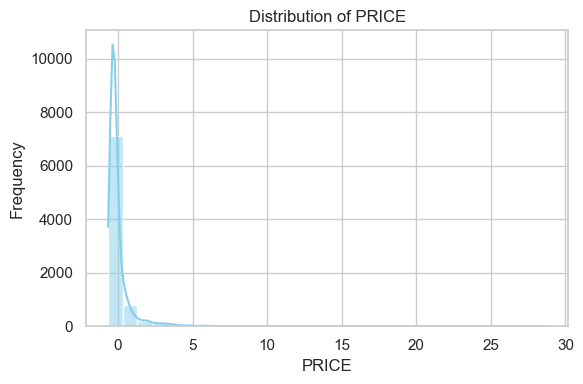

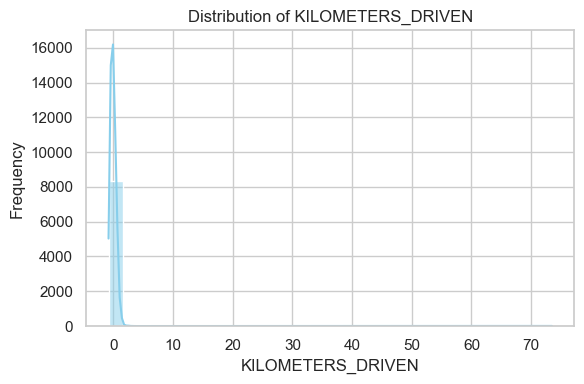

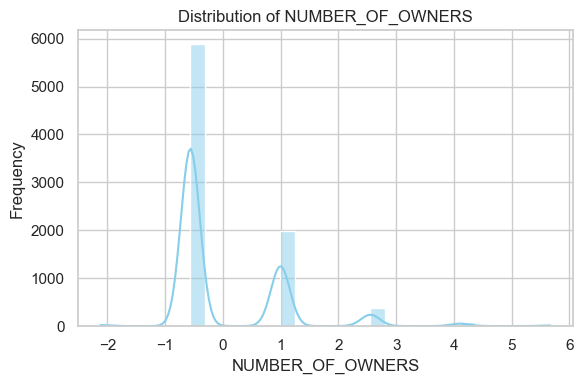

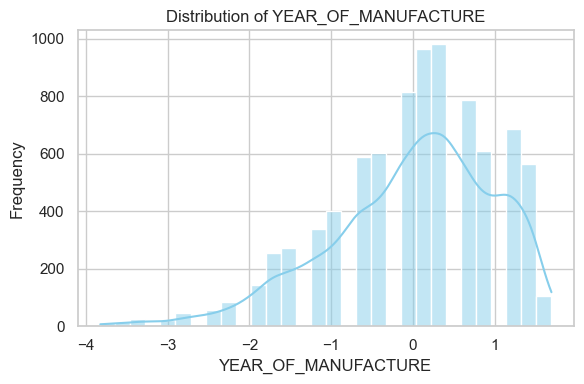

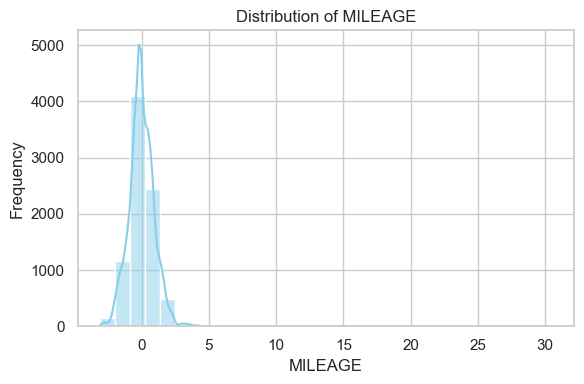

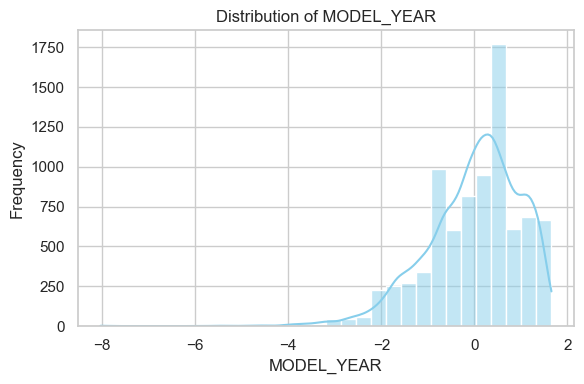

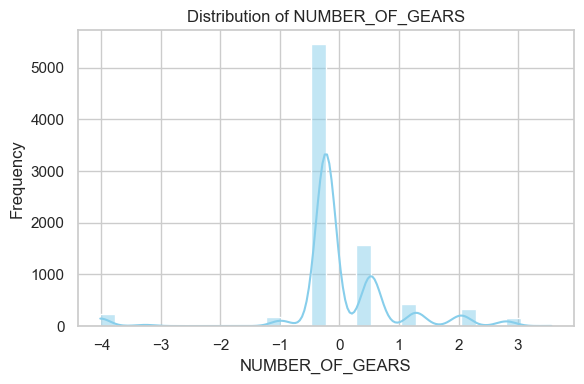

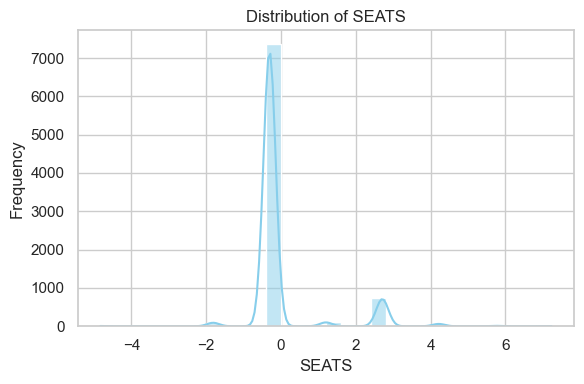

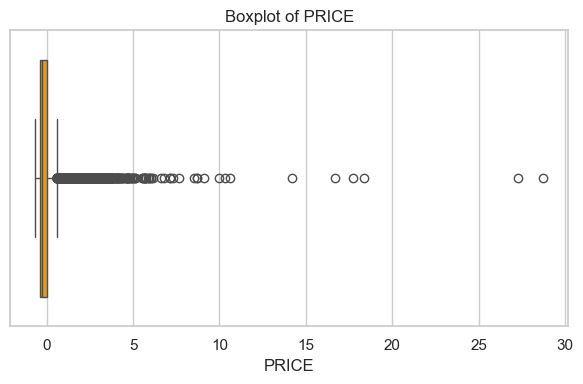

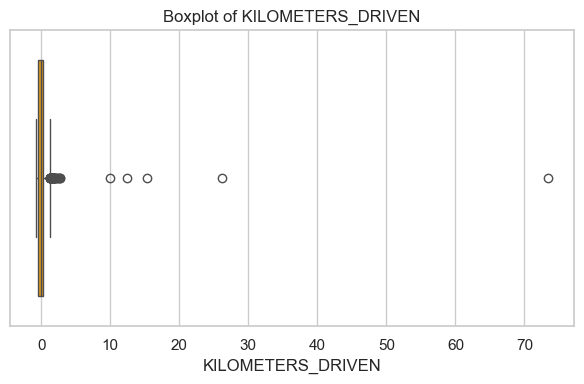

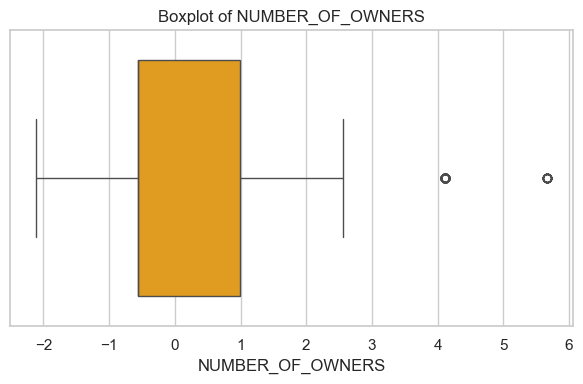

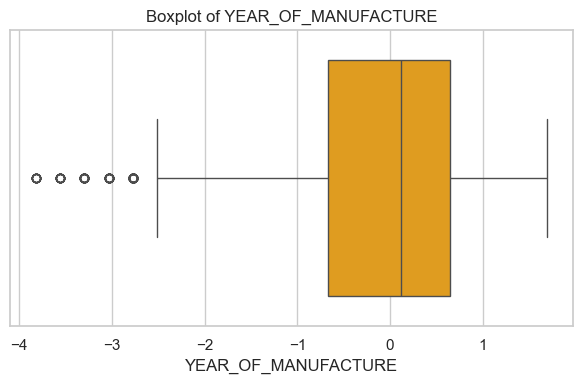

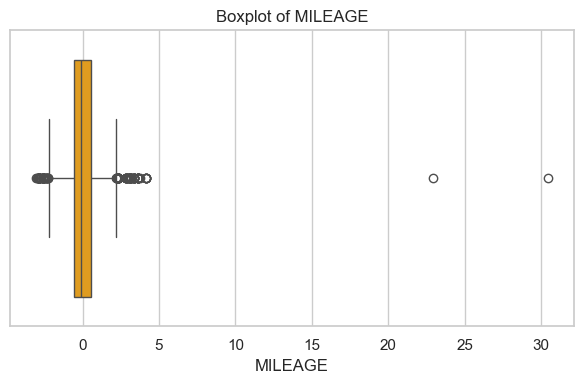

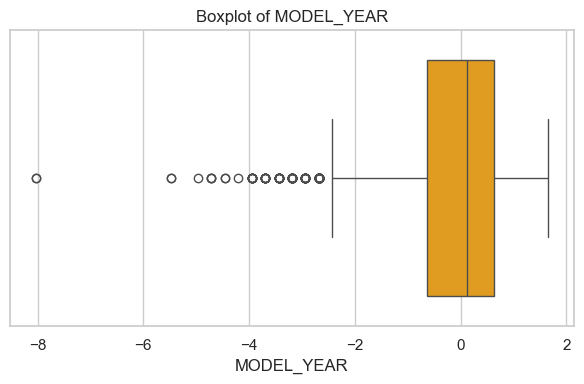

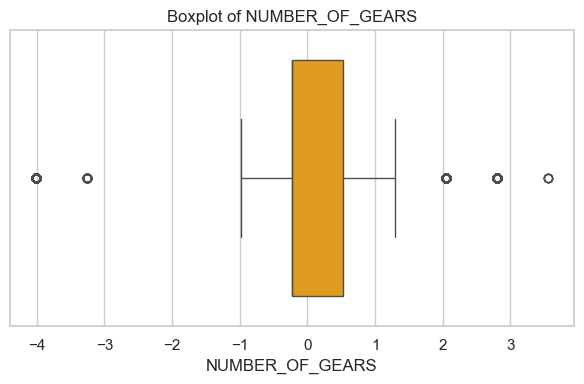

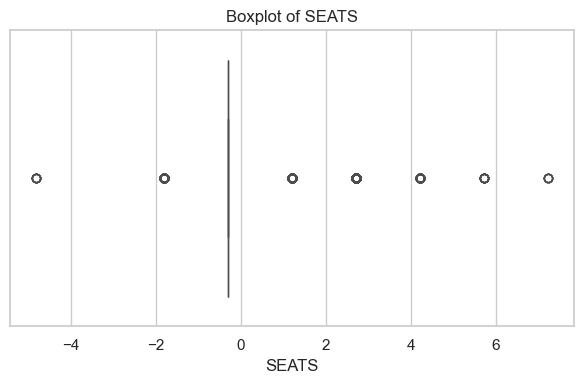

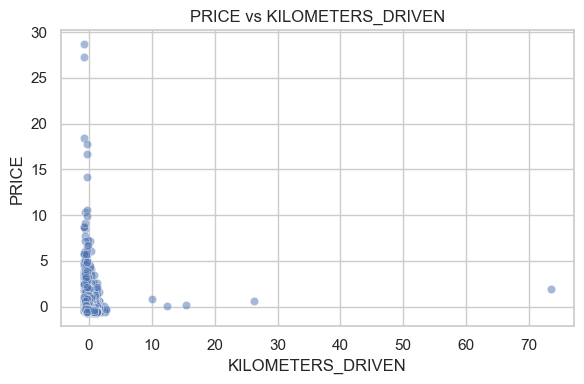

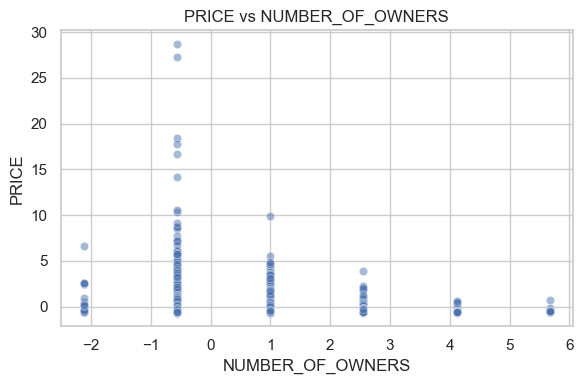

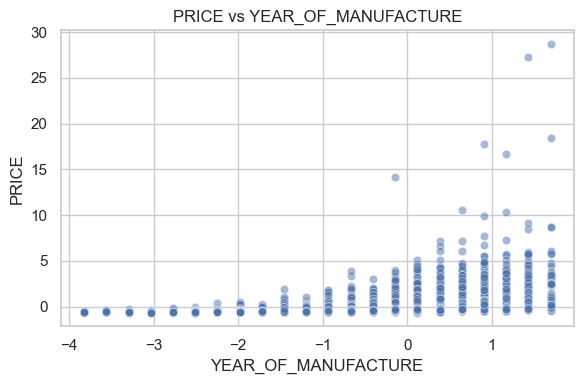

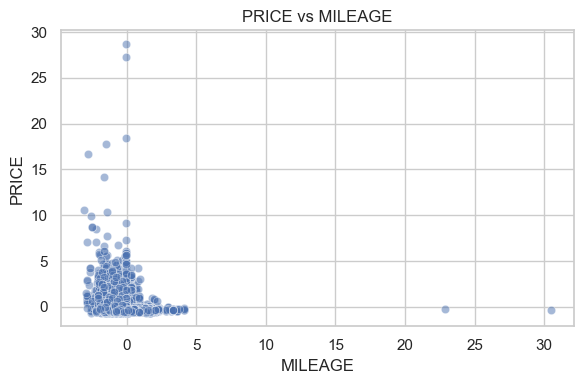

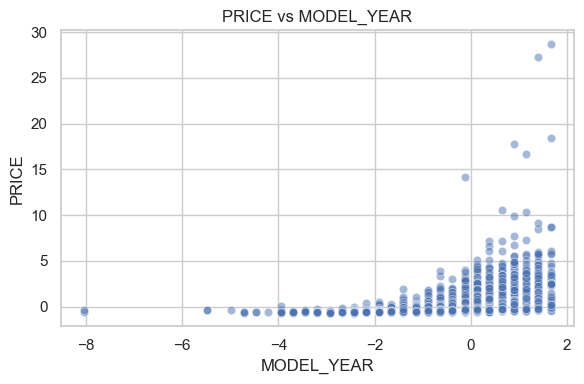

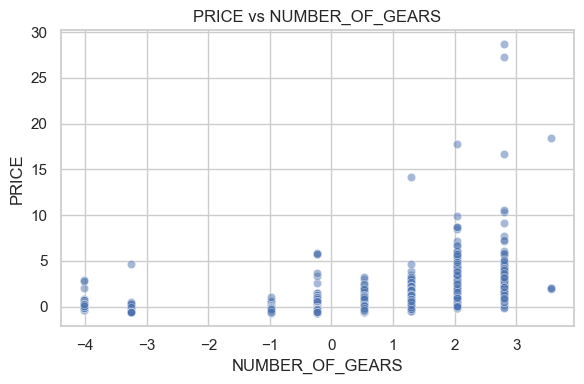

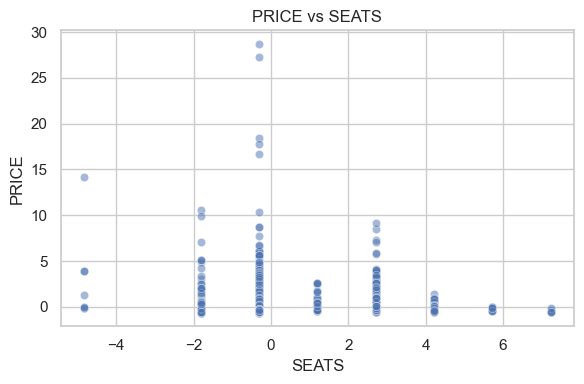

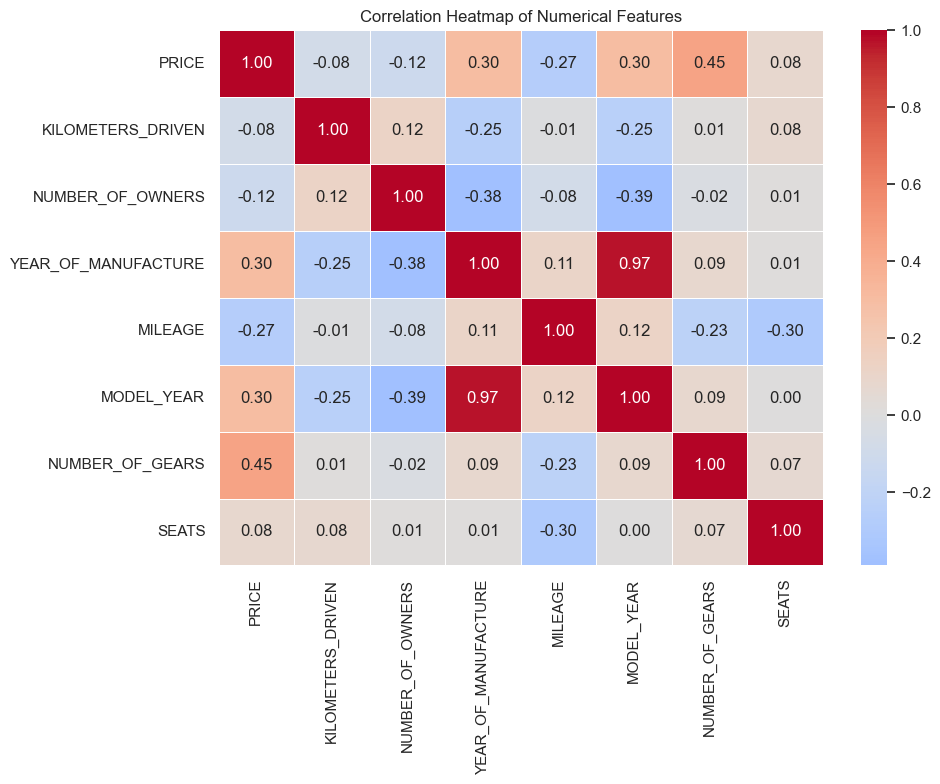

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\cars_encoded_StandardScaler.csv")

# Select numerical columns
numerical_cols = ['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE',
                  'MILEAGE', 'MODEL_YEAR', 'NUMBER_OF_GEARS', 'SEATS']

# Set a consistent style
sns.set(style="whitegrid")

# ---------- 1. HISTOGRAMS ----------
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# ---------- 2. BOXPLOTS ----------
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# ---------- 3. SCATTER PLOTS ----------
# Example: PRICE vs all other features
for col in numerical_cols:
    if col != 'PRICE':
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[col], y=df['PRICE'], alpha=0.5)
        plt.title(f'PRICE vs {col}')
        plt.xlabel(col)
        plt.ylabel('PRICE')
        plt.tight_layout()
        plt.show()

# ---------- 4. CORRELATION HEATMAP ----------
plt.figure(figsize=(10, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


npnpnpnpnp


=== DISTRIBUTION ANALYSIS ===


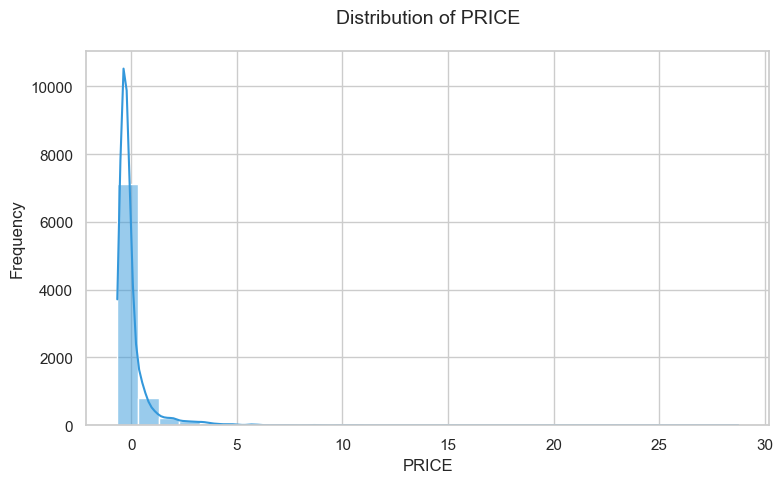

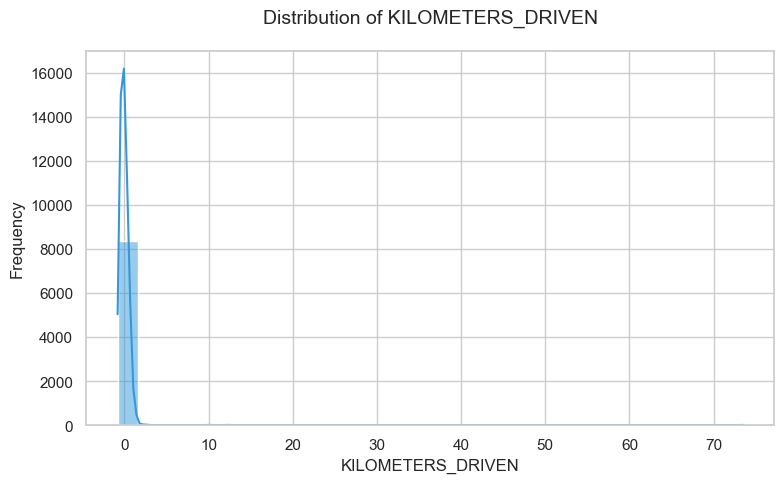

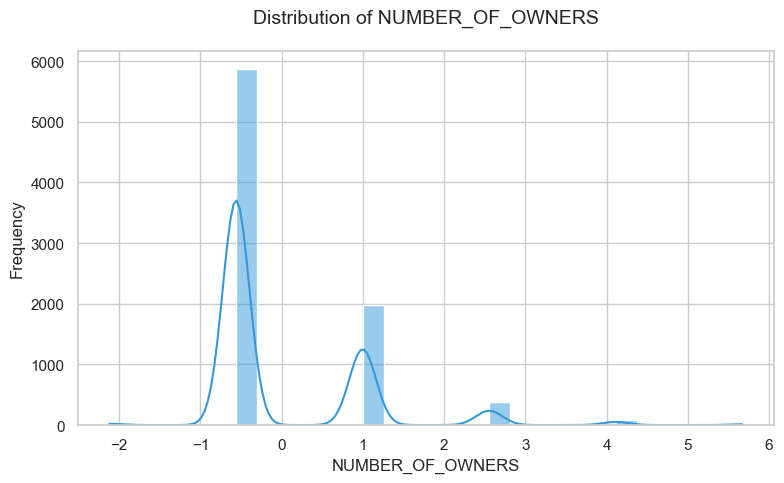

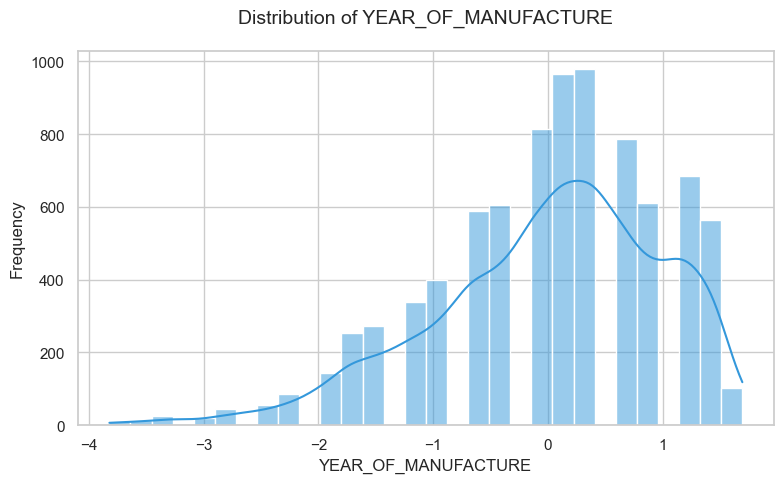

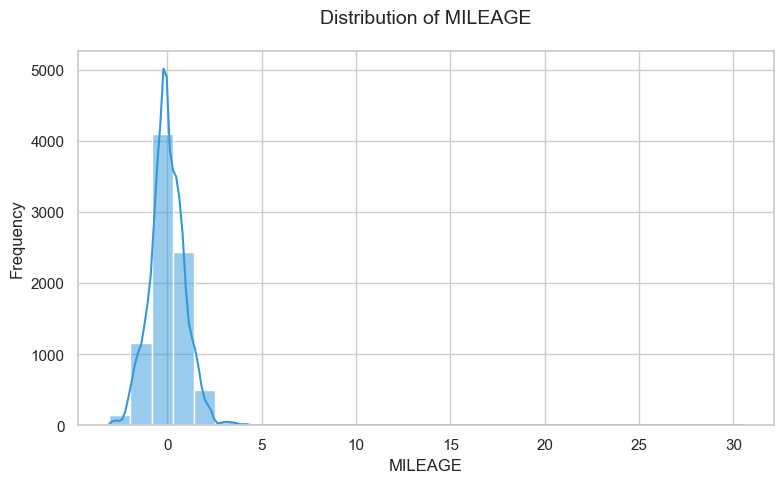

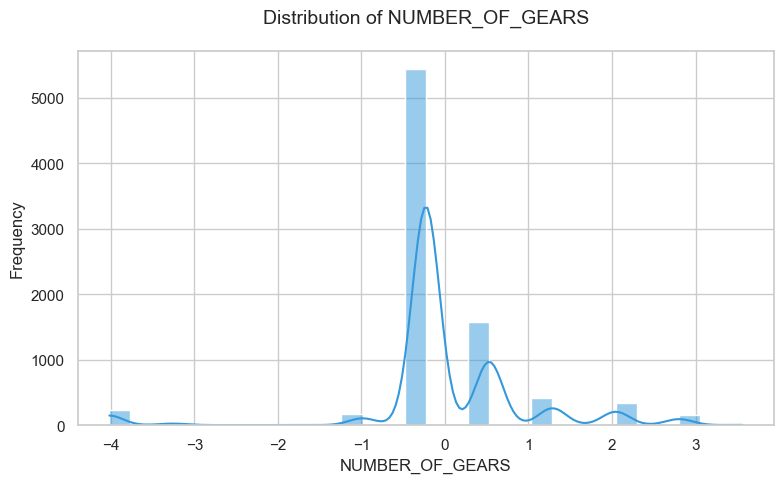

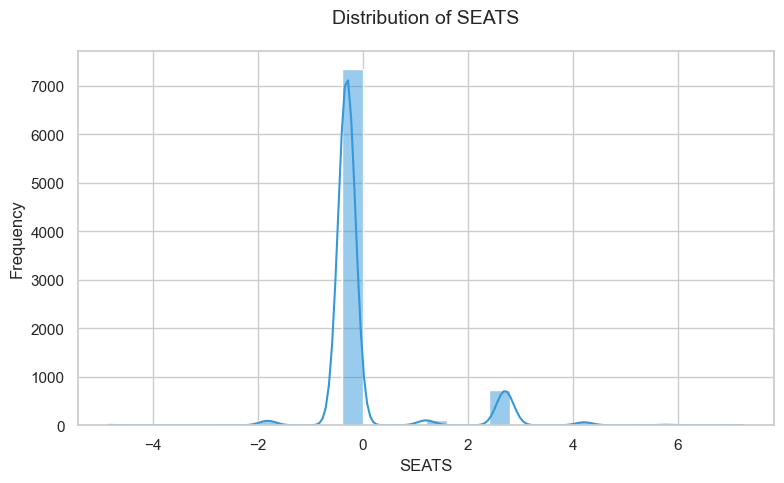

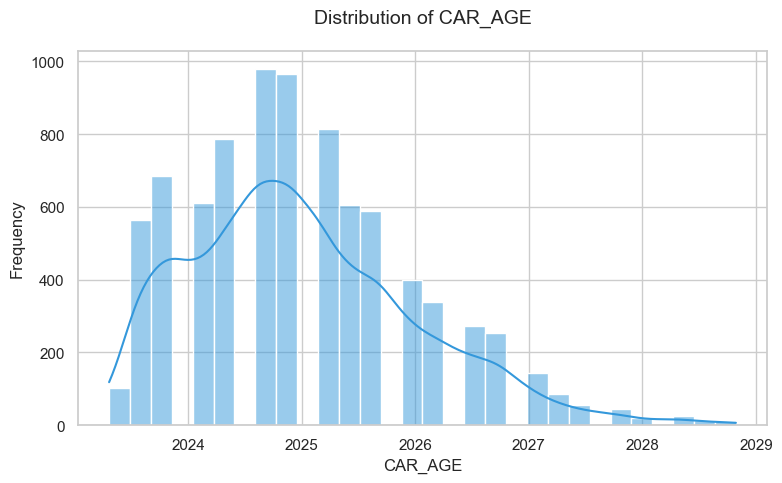


=== OUTLIER ANALYSIS ===


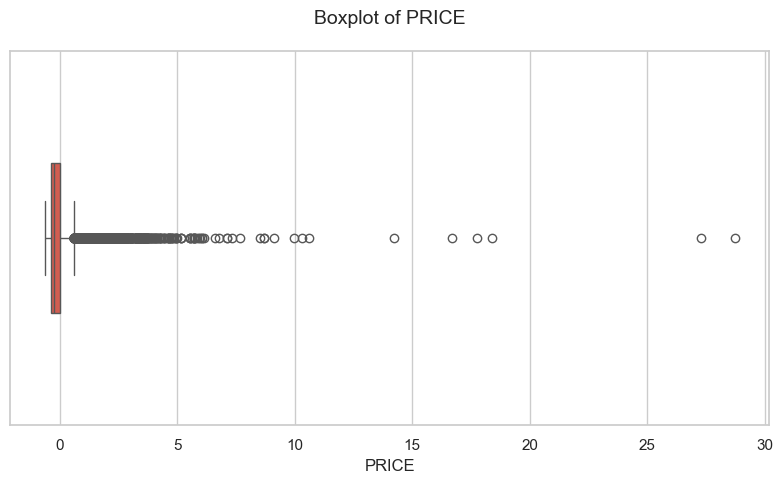

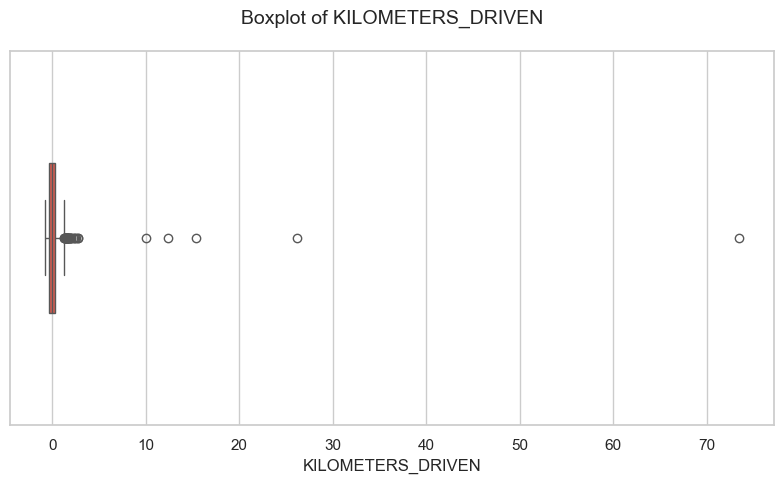

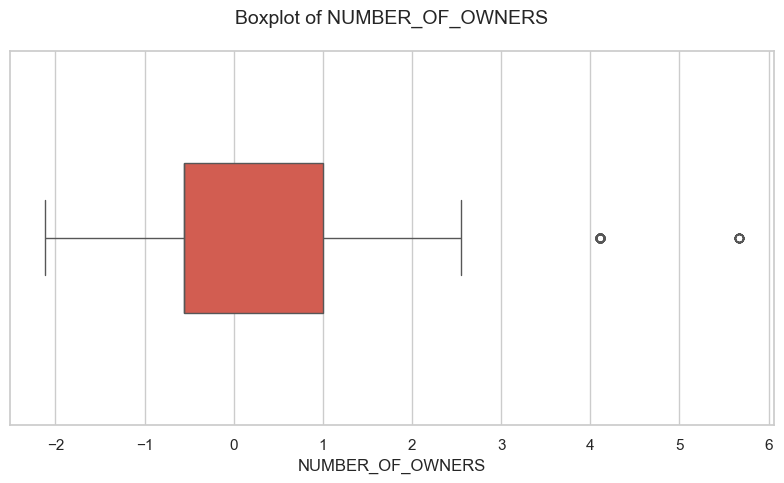

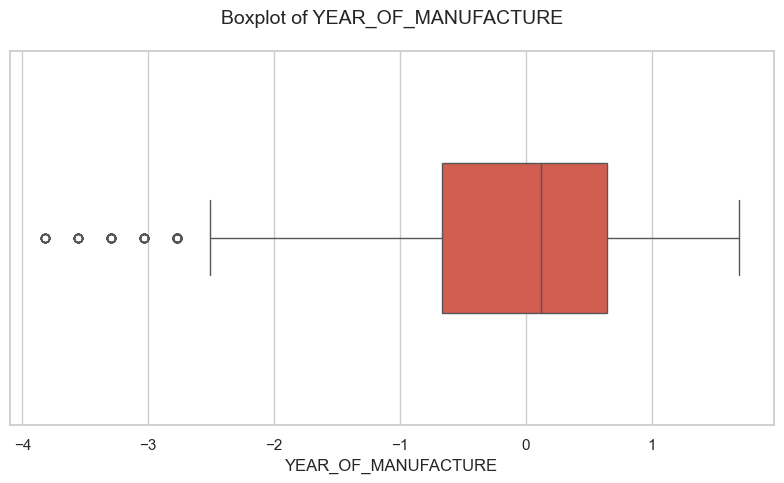

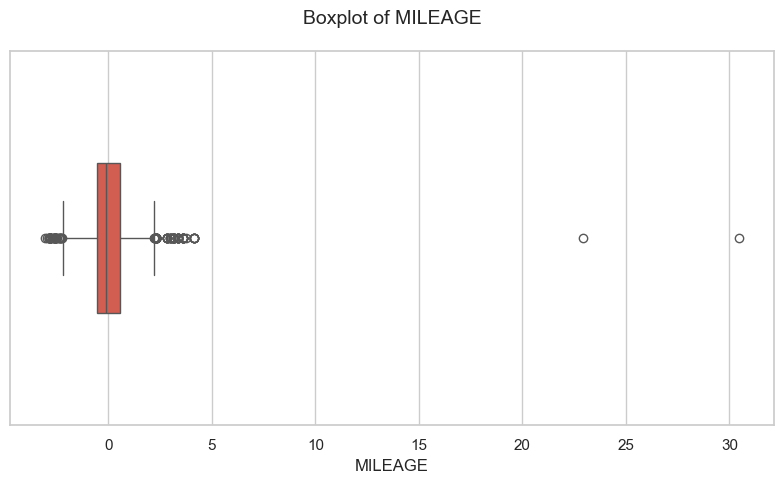

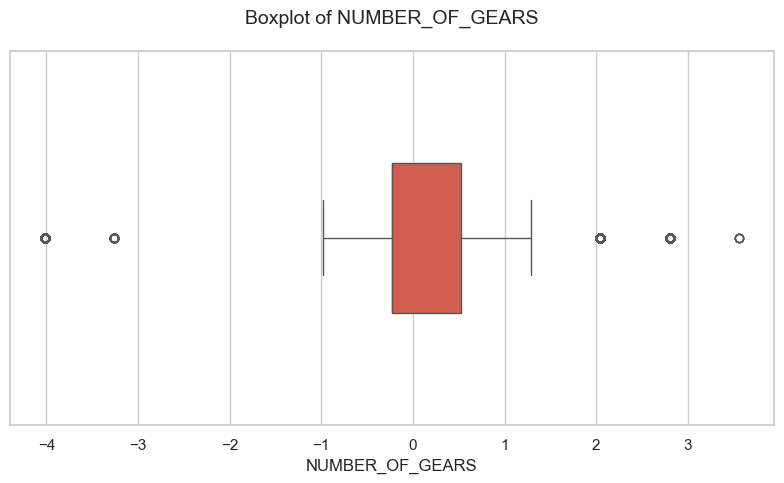

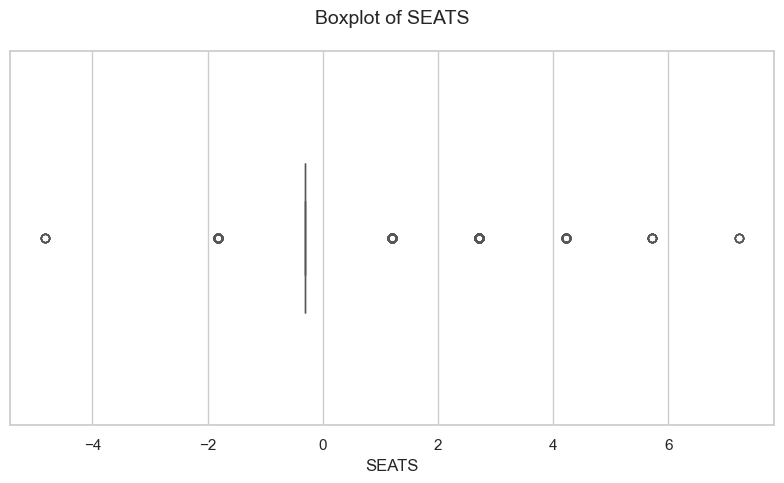

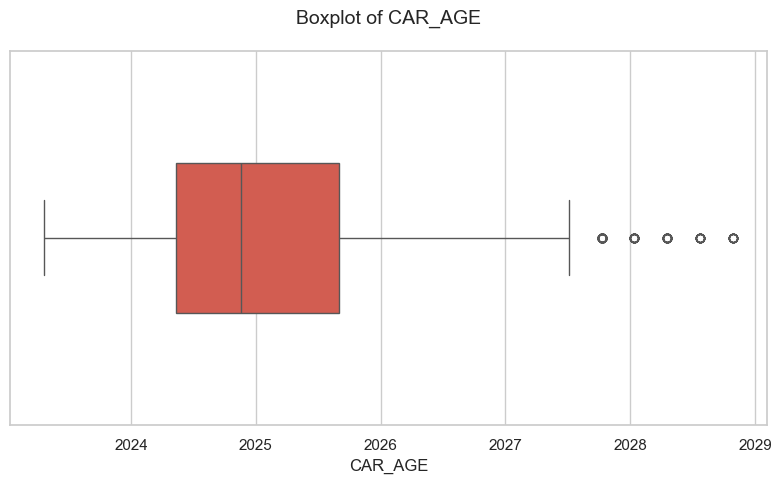


=== PRICE RELATIONSHIPS ===


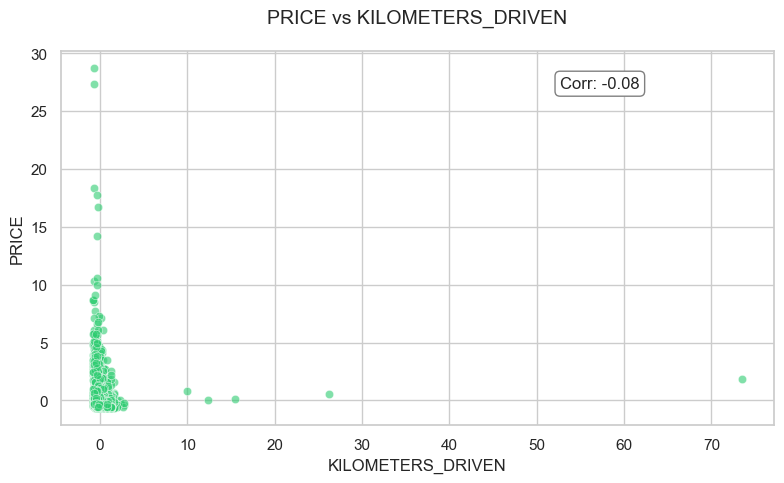

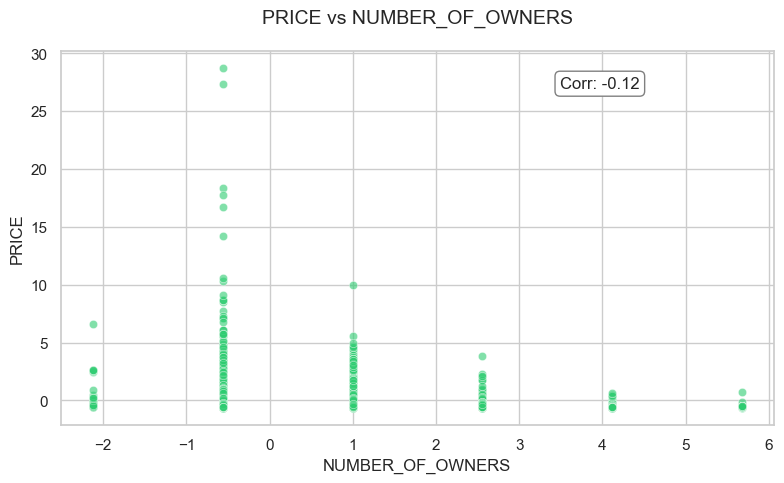

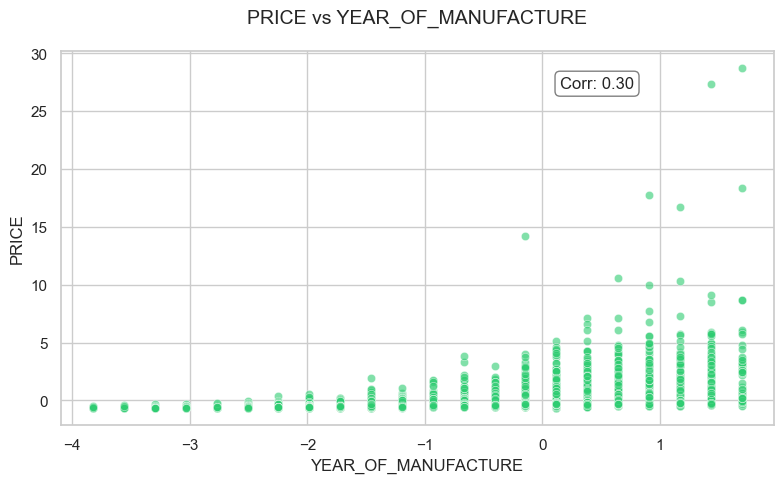

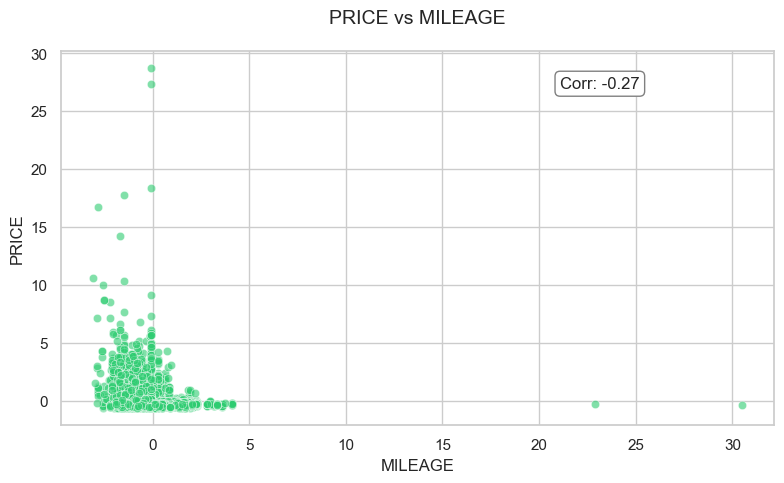

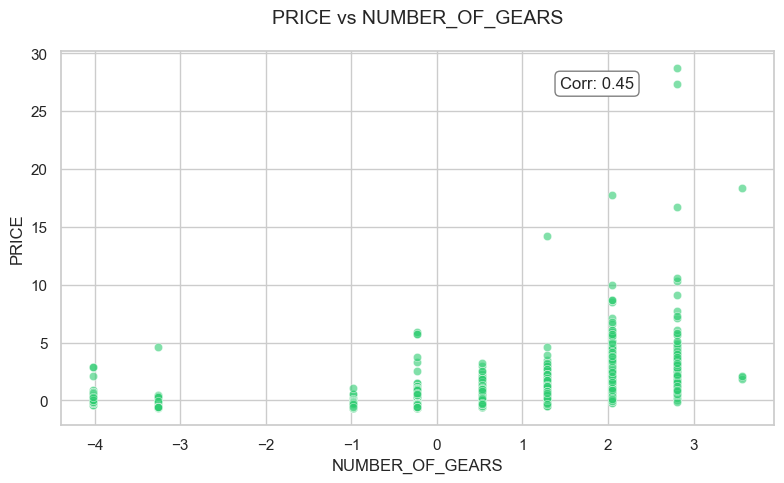

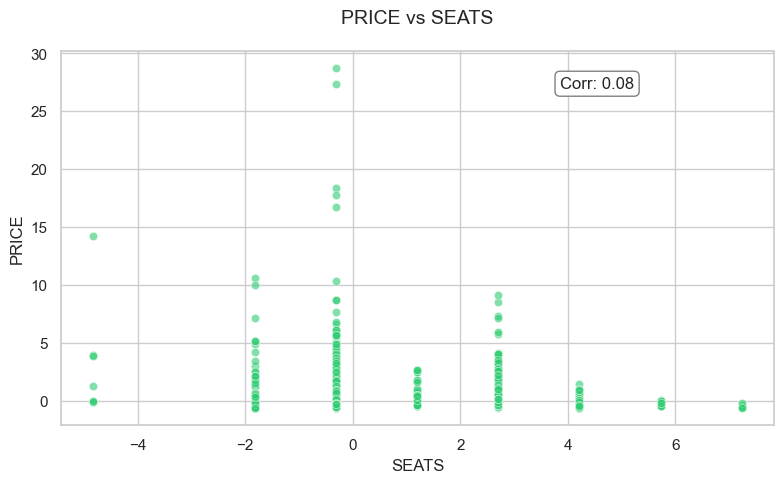

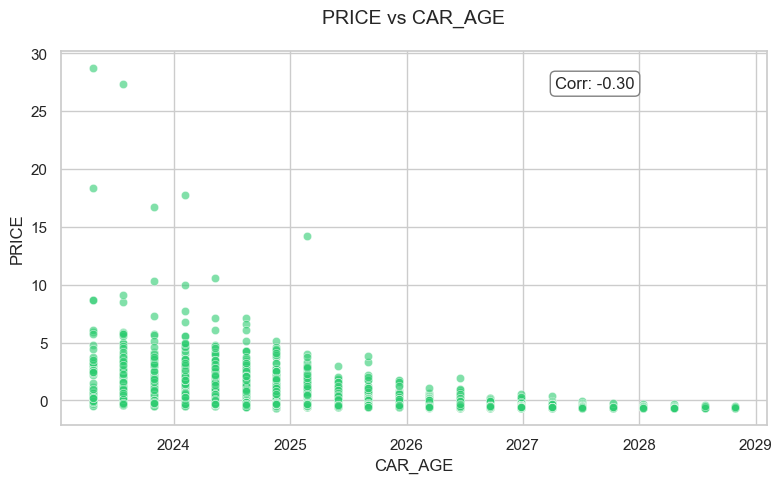


Price Correlations:
               Feature  Correlation
4      NUMBER_OF_GEARS     0.450888
2  YEAR_OF_MANUFACTURE     0.301828
5                SEATS     0.081631
0    KILOMETERS_DRIVEN    -0.077212
1     NUMBER_OF_OWNERS    -0.120362
3              MILEAGE    -0.265782
6              CAR_AGE    -0.301828


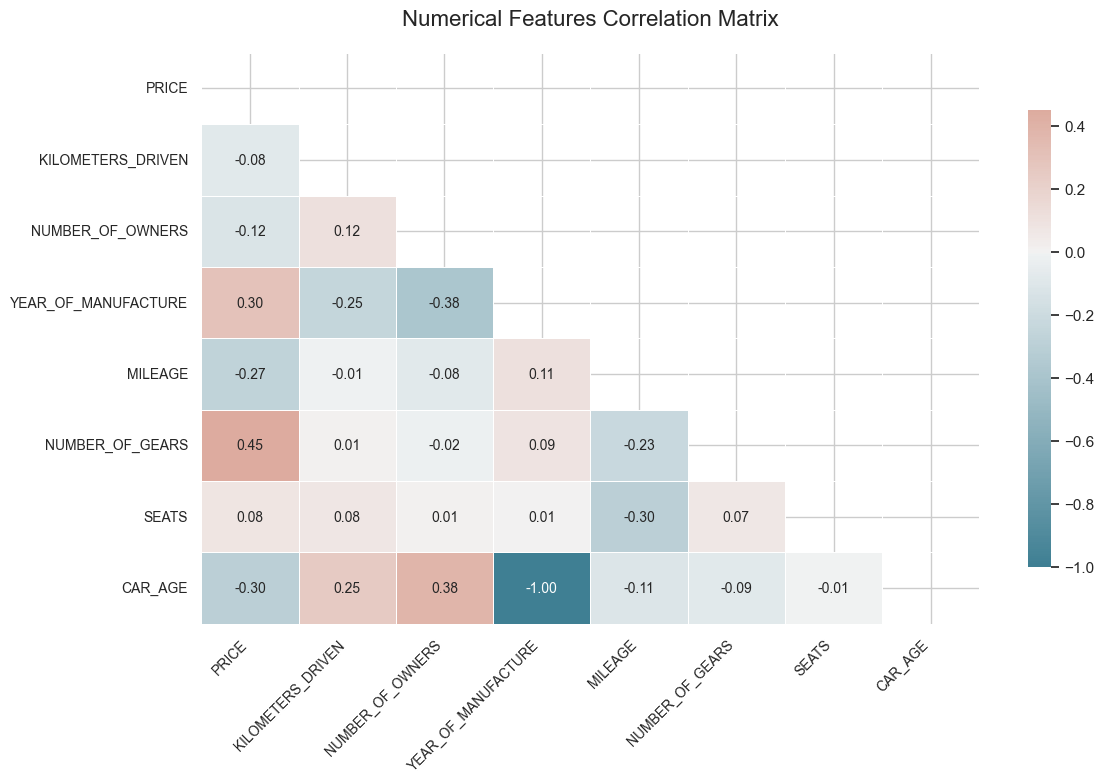

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Load dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\cars_encoded_StandardScaler.csv")

# =================================================================
# FEATURE ENGINEERING
# =================================================================

# Remove MODEL_YEAR (duplicate of YEAR_OF_MANUFACTURE)
numerical_cols = ['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 
                 'YEAR_OF_MANUFACTURE', 'MILEAGE', 'NUMBER_OF_GEARS', 'SEATS']

# Create CAR_AGE feature
current_year = datetime.datetime.now().year
df['CAR_AGE'] = current_year - df['YEAR_OF_MANUFACTURE']
numerical_cols.append('CAR_AGE')

# =================================================================
# VISUALIZATIONS (UPDATED)
# =================================================================

# Set style
sns.set(style="whitegrid", palette="pastel")

# ---------- 1. HISTOGRAMS ----------
print("\n=== DISTRIBUTION ANALYSIS ===")
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], bins=30, kde=True, color='#3498db')
    plt.title(f'Distribution of {col}', fontsize=14, pad=20)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.show()

# ---------- 2. BOXPLOTS ----------
print("\n=== OUTLIER ANALYSIS ===")
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color='#e74c3c', width=0.4)
    plt.title(f'Boxplot of {col}', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# ---------- 3. SCATTER PLOTS (vs PRICE) ----------
print("\n=== PRICE RELATIONSHIPS ===")
price_correlations = []
for col in numerical_cols:
    if col != 'PRICE':
        plt.figure(figsize=(8, 5))
        sns.scatterplot(x=df[col], y=df['PRICE'], alpha=0.6, color='#2ecc71')
        
        # Add correlation annotation
        corr = df['PRICE'].corr(df[col])
        plt.annotate(f'Corr: {corr:.2f}', xy=(0.7, 0.9), xycoords='axes fraction',
                    bbox=dict(boxstyle='round', fc='white', ec='gray'))
        
        plt.title(f'PRICE vs {col}', fontsize=14, pad=20)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('PRICE', fontsize=12)
        plt.tight_layout()
        plt.show()
        price_correlations.append((col, corr))

# Display price correlations sorted
print("\nPrice Correlations:")
print(pd.DataFrame(price_correlations, columns=['Feature', 'Correlation'])
      .sort_values('Correlation', ascending=False))

# ---------- 4. CORRELATION HEATMAP (UPDATED) ----------
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Custom diverging colormap
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, center=0,
            fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})

plt.title('Numerical Features Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

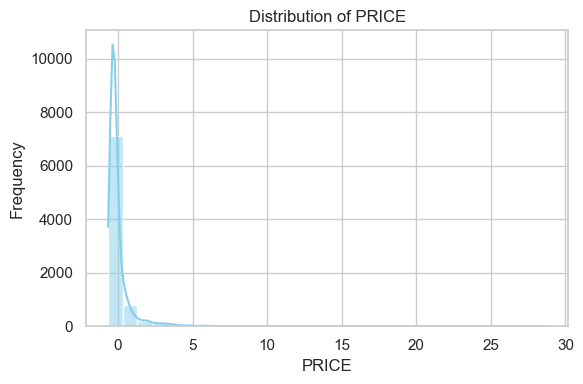

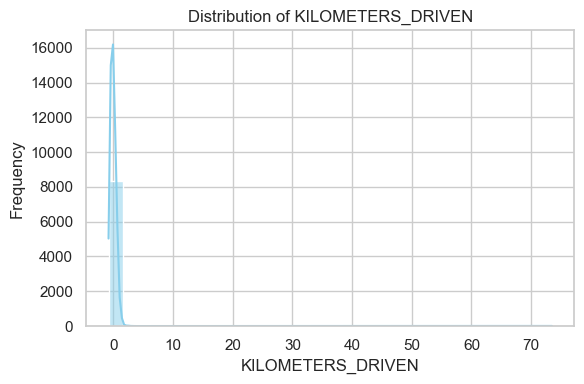

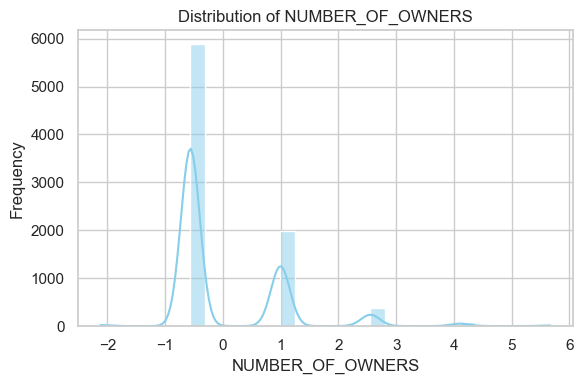

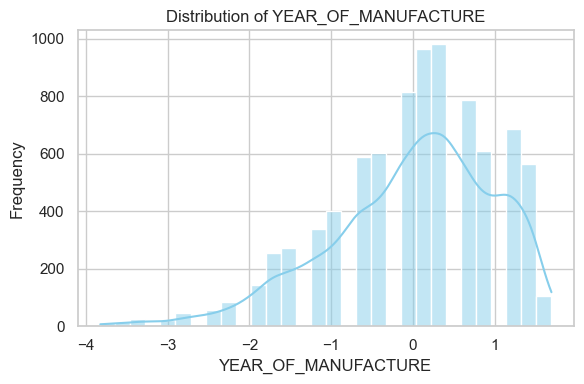

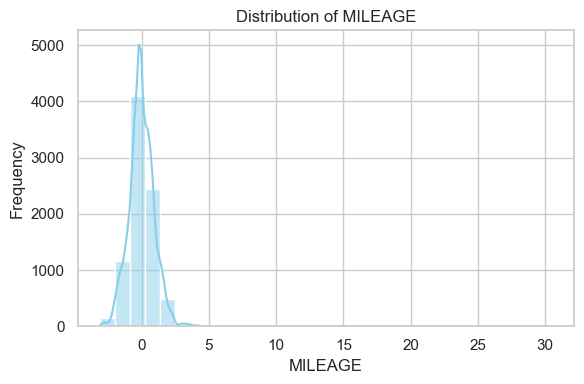

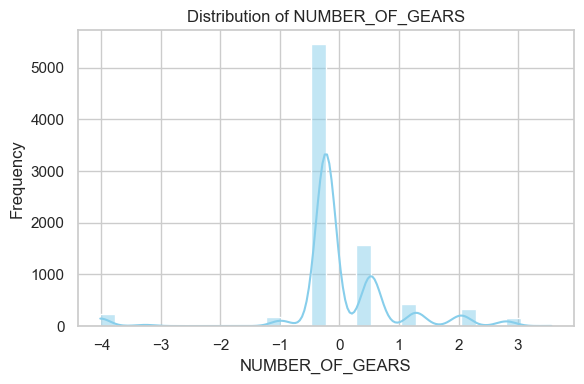

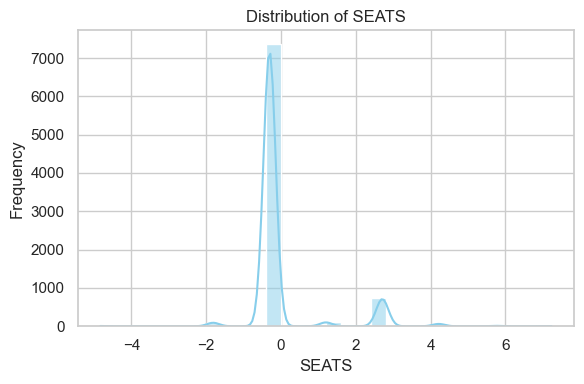

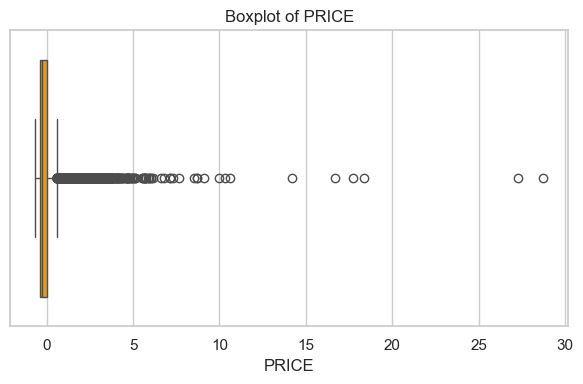

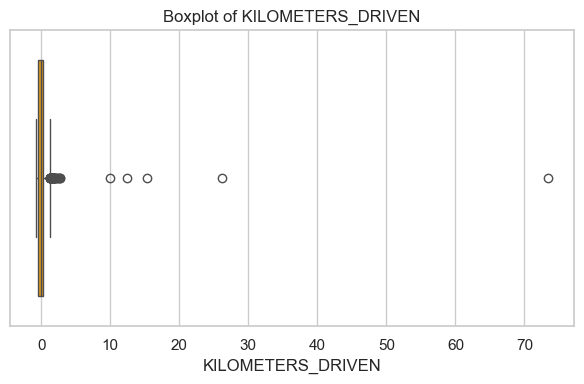

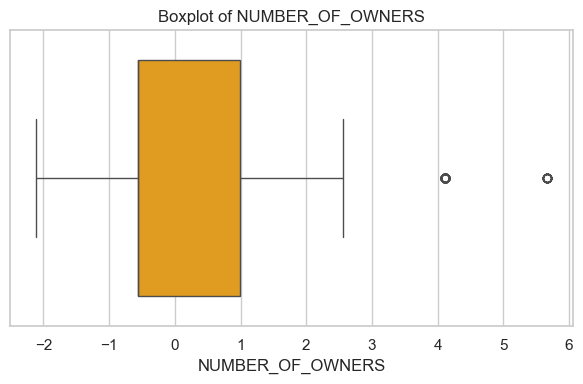

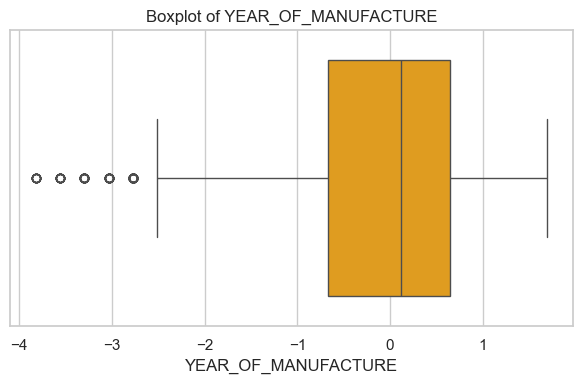

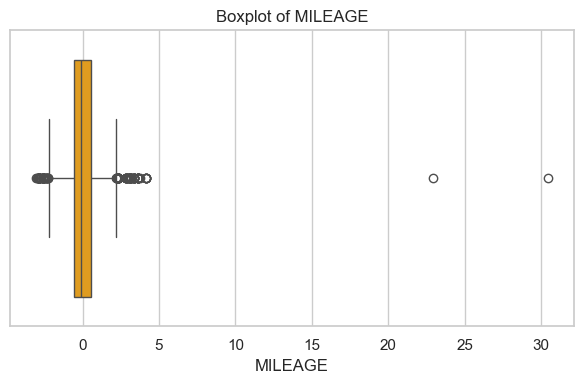

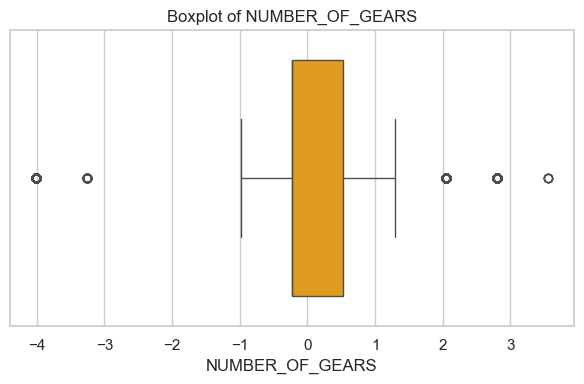

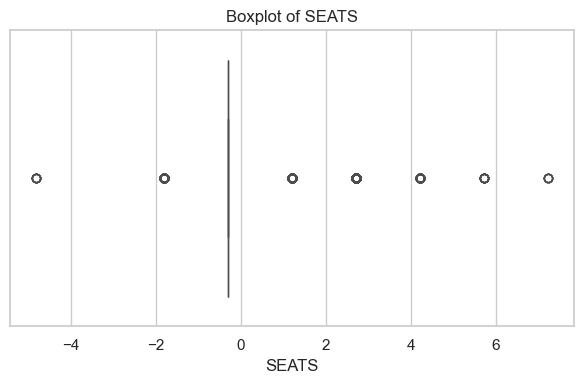

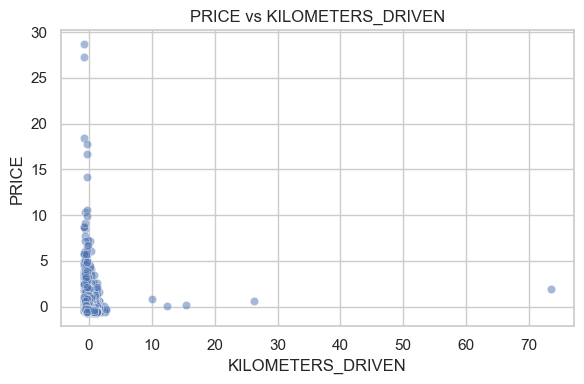

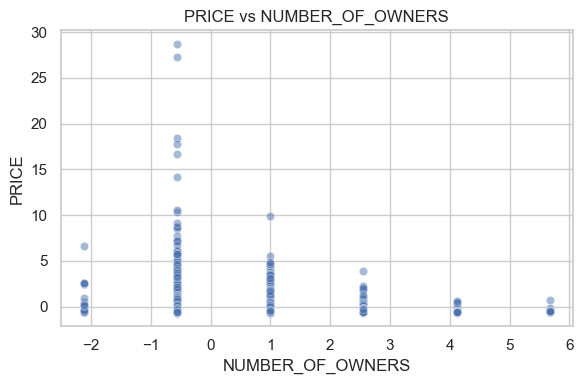

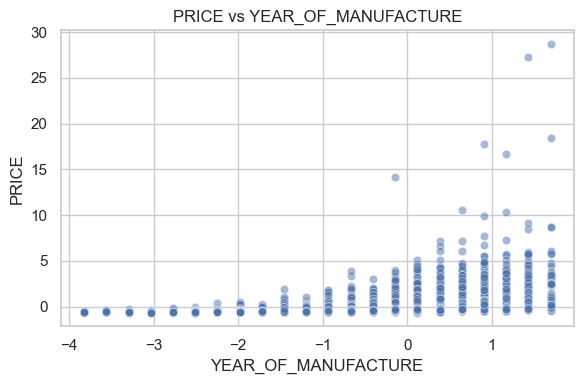

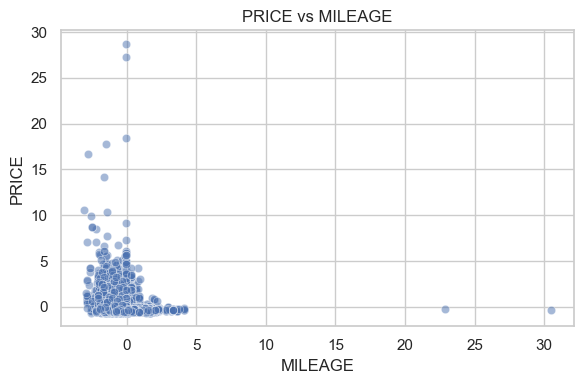

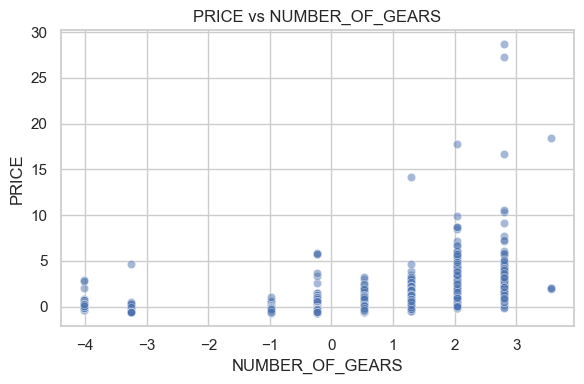

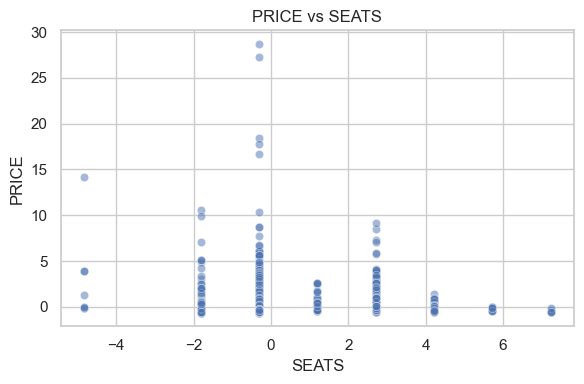

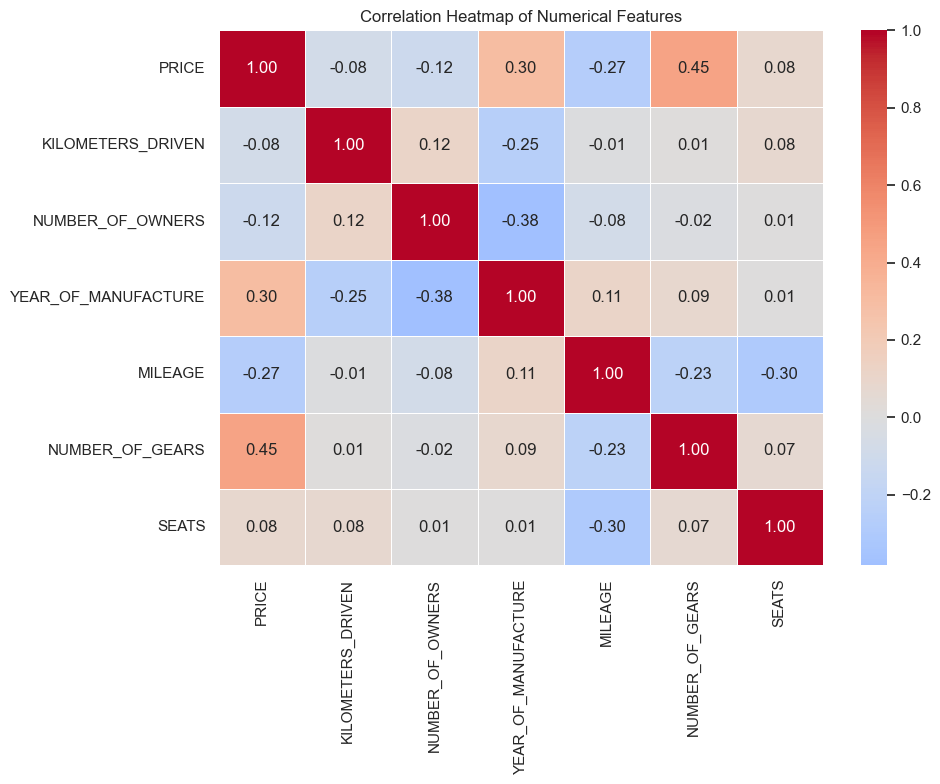

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\cars_encoded_StandardScaler.csv")

# Select numerical columns
numerical_cols = ['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE',
                  'MILEAGE', 'NUMBER_OF_GEARS', 'SEATS']

# Set a consistent style
sns.set(style="whitegrid")

# ---------- 1. HISTOGRAMS ----------
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# ---------- 2. BOXPLOTS ----------
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# ---------- 3. SCATTER PLOTS ----------
# Example: PRICE vs all other features
for col in numerical_cols:
    if col != 'PRICE':
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[col], y=df['PRICE'], alpha=0.5)
        plt.title(f'PRICE vs {col}')
        plt.xlabel(col)
        plt.ylabel('PRICE')
        plt.tight_layout()
        plt.show()

# ---------- 4. CORRELATION HEATMAP ----------
plt.figure(figsize=(10, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


c)	Feature Selection: Identify important features that significantly impact the car prices.

i)	Use techniques like correlation analysis, feature importance from models, and domain knowledge.


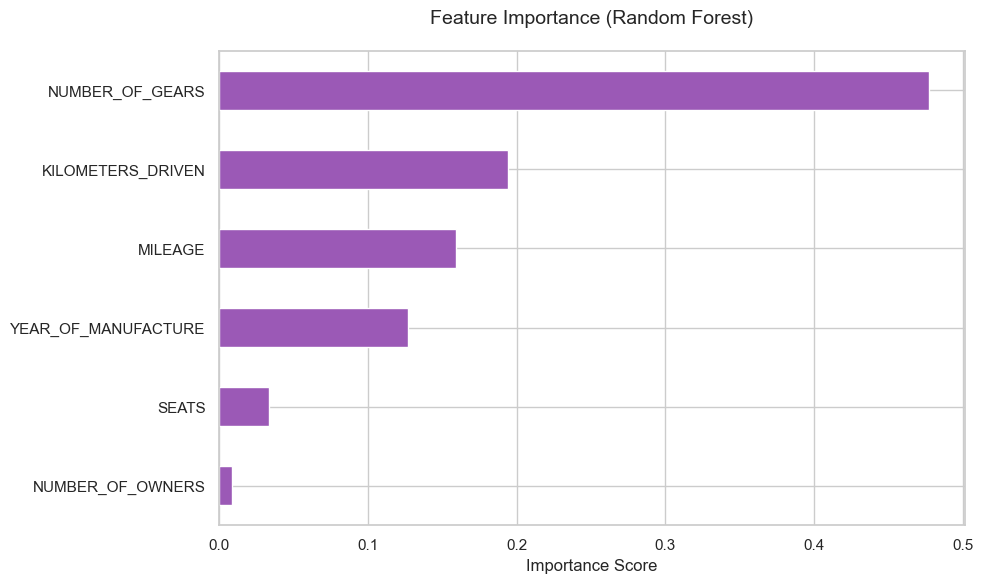

In [12]:
#(Random Forest)
# =================================================================
from sklearn.ensemble import RandomForestRegressor

# Prepare data
X = df[numerical_cols].drop('PRICE', axis=1)
y = df['PRICE']

# Fit model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Plot importance
plt.figure(figsize=(10, 6))
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot.barh(color='#9b59b6')
plt.title('Feature Importance (Random Forest)', fontsize=14, pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_4620\45438279.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.index, y=price_corr['PRICE'], palette='viridis')


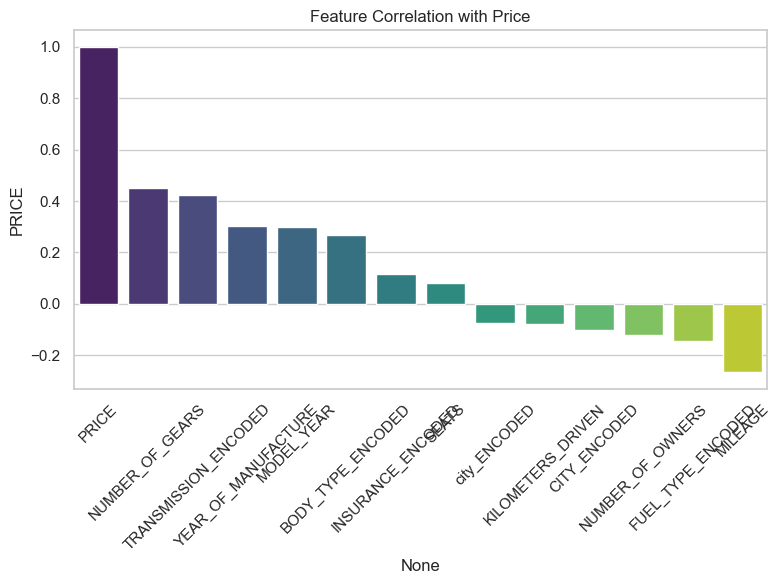

Top Correlated Features:
                         PRICE
PRICE                 1.000000
NUMBER_OF_GEARS       0.450888
TRANSMISSION_ENCODED  0.422600
YEAR_OF_MANUFACTURE   0.301828
MODEL_YEAR            0.299077
BODY_TYPE_ENCODED     0.268511
INSURANCE_ENCODED     0.114927
SEATS                 0.081631
city_ENCODED         -0.075682
KILOMETERS_DRIVEN    -0.077212
CITY_ENCODED         -0.102199
NUMBER_OF_OWNERS     -0.120362
FUEL_TYPE_ENCODED    -0.145570
MILEAGE              -0.265782


In [13]:
# Calculate correlations with PRICE
price_corr = df.corr(numeric_only=True)[['PRICE']].sort_values('PRICE', ascending=False)

# Visualize
plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.index, y=price_corr['PRICE'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Feature Correlation with Price')
plt.tight_layout()
plt.show()

print("Top Correlated Features:")
print(price_corr)

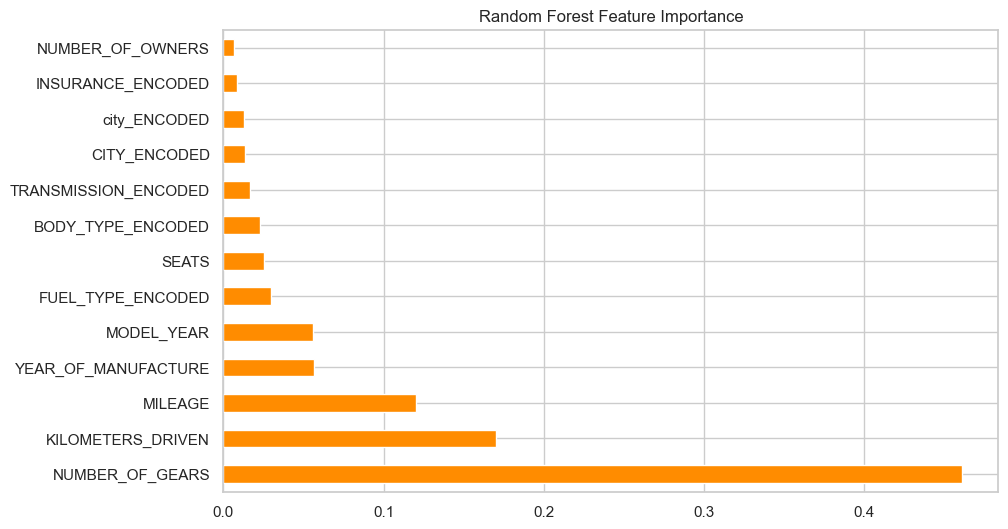

In [14]:
from sklearn.ensemble import RandomForestRegressor

# Prepare data
X = df.drop('PRICE', axis=1).select_dtypes(include=np.number)
y = df['PRICE']

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Get importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importance.plot.barh(color='darkorange')
plt.title('Random Forest Feature Importance')
plt.show()

In [5]:
domain_priority_features = [
    'YEAR_OF_MANUFACTURE',  # Newer cars cost more
    'MILEAGE',              # Lower mileage = higher price
    'NUMBER_OF_OWNERS',     # Fewer owners = better value
    'NUMBER_OF_GEARS',      # More gears → premium models
    'INSURANCE_TYPE',       # Comprehensive insurance adds value
    'TRANSMISSION'          # Automatics often more expensive
]

In [15]:
# Verify available columns first
print("Available columns in your DataFrame:")
print(df.columns.tolist())

# Step 1: Select only EXISTING numerical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print("\nNumerical features available:")
print(numerical_cols)

# Step 2: Correlation analysis (using only existing numerical features)
price_corr = df[numerical_cols].corr()[['PRICE']].sort_values('PRICE', ascending=False)
selected_features = price_corr[abs(price_corr['PRICE']) > 0.15].index.tolist()

# Step 3: Add categorical features (only if they exist)
categorical_candidates = ['TRANSMISSION', 'INSURANCE_TYPE'] 
existing_categorical = [col for col in categorical_candidates if col in df.columns]

if existing_categorical:
    # One-hot encode existing categorical features
    df_processed = pd.get_dummies(df, columns=existing_categorical)
    # Add the dummy columns to selected features
    selected_features.extend([col for col in df_processed.columns 
                            if any(x in col for x in [f"{cat}_" for cat in existing_categorical])])
else:
    df_processed = df.copy()
    print("\nNote: No categorical features available from the candidate list")

# Step 4: VIF analysis (only for numerical features)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare data (exclude PRICE and non-numerical)
X = df_processed[selected_features].drop('PRICE', errors='ignore').select_dtypes(include=np.number)

if not X.empty:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(len(X.columns))]
    
    # Get low VIF features
    low_vif_features = vif_data[vif_data["VIF"] < 5]['feature']
    final_features = ['PRICE'] + list(low_vif_features)
    
    # Add back categorical dummies
    final_features.extend([col for col in selected_features if col not in X.columns])
else:
    final_features = ['PRICE'] + selected_features

print("\nFinal Selected Features:")
print(final_features)

Available columns in your DataFrame:
['PRICE', 'BODY_TYPE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE', 'MILEAGE', 'FUEL_TYPE', 'MODEL_YEAR', 'INSURANCE_VALIDITY', 'NUMBER_OF_GEARS', 'TRANSMISSION', 'SEATS', 'CITY_NAME', 'INSURANCE_ENCODED', 'INSURANCE_MAPPED', 'CITY_ENCODED', 'TRANSMISSION_ENCODED', 'BODY_TYPE_ENCODED', 'city_ENCODED', 'FUEL_TYPE_ENCODED']

Numerical features available:
['PRICE', 'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE', 'MILEAGE', 'MODEL_YEAR', 'NUMBER_OF_GEARS', 'SEATS', 'INSURANCE_ENCODED', 'CITY_ENCODED', 'TRANSMISSION_ENCODED', 'BODY_TYPE_ENCODED', 'city_ENCODED', 'FUEL_TYPE_ENCODED']

Final Selected Features:
['PRICE', 'PRICE', 'NUMBER_OF_GEARS', 'BODY_TYPE_ENCODED', 'MILEAGE', 'TRANSMISSION_Automatic', 'TRANSMISSION_Manual']


c:\Users\USER\Desktop\Car-Dheko_Used_Car_Price_Prediction\.venv\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


save the finla features for streamlit 

In [16]:
import joblib

# ... (Your existing notebook code, including model training) ...

# Save the TUNED model and final features
final_model = random_search.best_estimator_  # Or your best model
final_features = ['PRICE', 'KILOMETERS_DRIVEN', 'YEAR_OF_MANUFACTURE', 'MILEAGE', 'Seats', 'FUEL_TYPE_Diesel', 'FUEL_TYPE_Petrol', 'TRANSMISSION_Manual']  # Replace with your ACTUAL final features list!

joblib.dump((final_model, final_features), 'tuned_gb_model_and_features.pkl')  # Save both
print("✅ Tuned Gradient Boosting model and features saved as tuned_gb_model_and_features.pkl")

NameError: name 'random_search' is not defined

In [18]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. PREPARE NUMERICAL FEATURES ------------------------------------
numerical_cols = [
    'KILOMETERS_DRIVEN', 'NUMBER_OF_OWNERS', 'YEAR_OF_MANUFACTURE',
    'MILEAGE', 'NUMBER_OF_GEARS', 'SEATS', 'INSURANCE_ENCODED',
    'CITY_ENCODED', 'TRANSMISSION_ENCODED', 'BODY_TYPE_ENCODED',
    'FUEL_TYPE_ENCODED'
]

# 2. CORRELATION ANALYSIS ------------------------------------------
price_corr = df[numerical_cols + ['PRICE']].corr()[['PRICE']].sort_values('PRICE', ascending=False)
strong_corr = price_corr[abs(price_corr['PRICE']) > 0.15].index.tolist()
strong_corr.remove('PRICE')  # Remove target variable

print("Features with strong correlation to PRICE:")
print(price_corr)

# 3. VIF ANALYSIS --------------------------------------------------
# Prepare data (only numerical features with strong correlation)
X_vif = df[strong_corr].select_dtypes(include=np.number)

# Handle zero division in VIF
with np.errstate(divide='ignore', invalid='ignore'):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                      for i in range(len(X_vif.columns))]
    
    # Replace inf/invalid values with high VIF
    vif_data["VIF"] = vif_data["VIF"].replace([np.inf, -np.inf], 1000).fillna(1000)

low_vif_features = vif_data[vif_data["VIF"] < 5]['feature'].tolist()

# 4. CATEGORICAL FEATURES -----------------------------------------
# Use pre-encoded versions (already in numerical_cols)
categorical_encoded = [
    'TRANSMISSION_ENCODED', 'BODY_TYPE_ENCODED', 
    'FUEL_TYPE_ENCODED', 'CITY_ENCODED'
]

# 5. FINAL FEATURE SELECTION --------------------------------------
final_features = low_vif_features + [
    col for col in categorical_encoded 
    if col in df.columns and col not in low_vif_features
]

# Add back any critical features that might have been removed
critical_features = ['NUMBER_OF_GEARS', 'YEAR_OF_MANUFACTURE']
for feat in critical_features:
    if feat not in final_features and feat in df.columns:
        final_features.append(feat)

print("\nSelected Features:")
print(final_features)

# 6. VERIFICATION ------------------------------------------------
print("\nFeature Importance Preview:")
from sklearn.ensemble import RandomForestRegressor
X_final = df[final_features]
y = df['PRICE']
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_final, y)
importance = pd.Series(rf.feature_importances_, index=X_final.columns)
print(importance.sort_values(ascending=False))

Features with strong correlation to PRICE:
                         PRICE
PRICE                 1.000000
NUMBER_OF_GEARS       0.450888
TRANSMISSION_ENCODED  0.422600
YEAR_OF_MANUFACTURE   0.301828
BODY_TYPE_ENCODED     0.268511
INSURANCE_ENCODED     0.114927
SEATS                 0.081631
KILOMETERS_DRIVEN    -0.077212
CITY_ENCODED         -0.102199
NUMBER_OF_OWNERS     -0.120362
FUEL_TYPE_ENCODED    -0.145570
MILEAGE              -0.265782

Selected Features:
['NUMBER_OF_GEARS', 'TRANSMISSION_ENCODED', 'YEAR_OF_MANUFACTURE', 'BODY_TYPE_ENCODED', 'MILEAGE', 'FUEL_TYPE_ENCODED', 'CITY_ENCODED']

Feature Importance Preview:
NUMBER_OF_GEARS         0.495522
MILEAGE                 0.183887
YEAR_OF_MANUFACTURE     0.163383
FUEL_TYPE_ENCODED       0.064983
BODY_TYPE_ENCODED       0.038495
CITY_ENCODED            0.037261
TRANSMISSION_ENCODED    0.016470
dtype: float64


3)	 Model Development

a)	Train-Test Split: Split the dataset into training and testing sets to evaluate model performance.

i)	Common split ratios are 70-30 or 80-20.


In [20]:

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the processed dataset if not already loaded
df = pd.read_csv('cars_encoded_StandardScaler.csv')

# Define input and target
X = df[final_features]
y = df['PRICE']

# Perform 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (6690, 7)
Testing set size: (1673, 7)


1️⃣ Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("\n🔹 Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R² Score:", r2_score(y_test, y_pred_lr))



🔹 Linear Regression:
MAE: 0.3507026112993782
MSE: 1.0660427064794866
RMSE: 1.0324934413735938
R² Score: 0.3167108706607089


2️⃣ Decision Tree Regressor

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n🔹 Decision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R² Score:", r2_score(y_test, y_pred_dt))



🔹 Decision Tree:
MAE: 0.18335037504687007
MSE: 0.6763758102311654
RMSE: 0.8224207014850523
R² Score: 0.5664711782464562


3️⃣ Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n🔹 Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² Score:", r2_score(y_test, y_pred_rf))



🔹 Random Forest:
MAE: 0.16023510266137678
MSE: 0.5891394227849828
RMSE: 0.7675541823122214
R² Score: 0.6223860819013542


4️⃣ Gradient Boosting Regressor

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("\n🔹 Gradient Boosting:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R² Score:", r2_score(y_test, y_pred_gb))



🔹 Gradient Boosting:
MAE: 0.20427830600919422
MSE: 0.551476684808493
RMSE: 0.7426147620459029
R² Score: 0.646526333773135


Model | MAE ↓ | RMSE ↓ | R² ↑

Linear Regression | 0.35 | 1.03 | 0.32

Decision Tree | 0.18 | 0.82 | 0.57

Random Forest | 0.16 | 0.77 | 0.62

Gradient Boosting | ⭐ 0.20 | ⭐ 0.74 | ⭐ 0.65

🔁 Cross-Validate Gradient Boosting Regressor

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

# Initialize model
gb_cv_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Perform 5-fold cross-validation using negative MSE (sklearn uses negative scores for loss functions)
cv_scores = cross_val_score(gb_cv_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Convert negative MSE to RMSE
rmse_scores = np.sqrt(-cv_scores)

print("🔁 Gradient Boosting Cross-Validation (5-Fold):")
print("RMSE Scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())


🔁 Gradient Boosting Cross-Validation (5-Fold):
RMSE Scores: [0.74979991 0.48119494 0.59612081 0.43390754 0.42001032]
Average RMSE: 0.5362067062085674
Standard Deviation: 0.12345425748403778


🔁 (Optional) Compare with Random Forest

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_cv_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_cv_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rf_rmse = np.sqrt(-rf_scores)

print("\n🔁 Random Forest Cross-Validation (5-Fold):")
print("RMSE Scores:", rf_rmse)
print("Average RMSE:", rf_rmse.mean())
print("Standard Deviation:", rf_rmse.std())



🔁 Random Forest Cross-Validation (5-Fold):
RMSE Scores: [0.71388916 0.52709438 0.66361539 0.39249733 0.3820376 ]
Average RMSE: 0.5358267726744292
Standard Deviation: 0.13587261453941682


Model | Average RMSE ↓ | Std Dev ↓

Gradient Boosting | 0.5362 | 0.1235

Random Forest | ⭐ 0.5358 | 0.1359

d)	Hyperparameter Tuning: Optimize model parameters to improve performance.

i)	Use techniques like Grid Search or Random Search.


🔎 Option A: Randomized Search (faster)

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform

# Define model
gb_model = GradientBoostingRegressor(random_state=42)

# Define hyperparameter search space
param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Randomized Search CV
random_search = RandomizedSearchCV(
    gb_model, param_distributions=param_dist,
    n_iter=30, cv=5, scoring='neg_mean_squared_error', 
    random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)

# Best model and score
print("✅ Best Parameters (Random Search):", random_search.best_params_)
print("🔢 Best RMSE:", np.sqrt(-random_search.best_score_))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Parameters (Random Search): {'learning_rate': np.float64(0.21497905564763747), 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 224}
🔢 Best RMSE: 0.5078144457402739


i have use this for the model in streamlit above random search

#  code 

In [36]:
import joblib
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# 1. FIRST LOAD YOUR DATA (if not already loaded)
# df_cars_1 = pd.read_csv('your_data.csv')  # Uncomment and replace with your actual data loading

# 2. DEFINE ENCODERS (only if you need to re-fit them)
# If you've already encoded your data, just create the encoders with the same parameters
# without fitting them again

# Insurance encoder (with categories but not fitted)
insurance_order = [
    'Not Available',
    '1', 
    '2',
    'Third Party', 
    'Third Party insurance',
    'Comprehensive',
    'Zero Dep'
]
insurance_encoder = OrdinalEncoder(categories=[insurance_order])

# City encoder
city_order = ['BANGALORE', 'DELHI', 'CHENNAI', 'HYDERABAD', 'JAIPUR', 'KOLKATA']
city_encoder = OrdinalEncoder(categories=[city_order])

# Fuel encoder
fuel_order = ['Electric', 'CNG', 'LPG', 'Diesel', 'Petrol']
fuel_encoder = OrdinalEncoder(categories=[fuel_order])

# Label encoder for body type (no categories needed)
body_type_encoder = LabelEncoder()

# 3. SAVE ENCODERS (without re-fitting if already fitted)
joblib.dump(insurance_encoder, 'insurance_encoder.pkl')
joblib.dump(city_encoder, 'city_encoder.pkl')
joblib.dump(fuel_encoder, 'fuel_encoder.pkl')
joblib.dump(body_type_encoder, 'body_type_encoder.pkl')

# 4. CREATE PIPELINE STRUCTURE
preprocessor = ColumnTransformer(
    transformers=[
        ('insurance', insurance_encoder, ['INSURANCE_VALIDITY']),
        ('city', city_encoder, ['CITY_NAME']),
        ('fuel', fuel_encoder, ['FUEL_TYPE']),
        ('transmission', 'passthrough', ['TRANSMISSION_ENCODED']),
        ('body_type', body_type_encoder, ['BODY_TYPE'])
    ])

# 5. SAVE COMPLETE PIPELINE (if you have the model)
if 'random_search' in globals():  # Only if you've already trained the model
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', random_search.best_estimator_)
    ])
    joblib.dump(full_pipeline, 'full_pipeline.pkl')

print("All encoders and pipeline saved successfully!")

All encoders and pipeline saved successfully!


In [ ]:
#2. Save Feature Names and Metadata

import json

# Define all required mapping variables first
insurance_mapping = {
    0.0: 'Not Available',
    1.0: '1',
    2.0: '2',
    3.0: 'Third Party',
    4.0: 'Third Party insurance',
    5.0: 'Comprehensive',
    6.0: 'Zero Dep'
}

city_order = ['BANGALORE', 'DELHI', 'CHENNAI', 'HYDERABAD', 'JAIPUR', 'KOLKATA']

fuel_order = ['Electric', 'CNG', 'LPG', 'Diesel', 'Petrol']

car_ranking = ['SUV', 'Sedan', 'Hatchback', 'MUV', 'Pickup Trucks', 'Hybrids', 
               'Wagon', 'Minivans', 'Coupe', 'Convertibles']

# Now create and save the metadata
metadata = {
    'final_features': ['PRICE', 'KILOMETERS_DRIVEN', 'YEAR_OF_MANUFACTURE', 
                      'MILEAGE', 'Seats', 'FUEL_TYPE_Diesel', 
                      'FUEL_TYPE_Petrol', 'TRANSMISSION_Manual'],
    'insurance_mapping': insurance_mapping,
    'city_order': city_order,
    'fuel_order': fuel_order,
    'car_ranking': car_ranking
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)  # indent=4 for pretty formatting

print("Metadata saved successfully to model_metadata.json")

Metadata saved successfully to model_metadata.json


In [40]:
# 3. Recommended Loading Approach in Streamlit
import joblib
import json

# Load everything at once
full_pipeline = joblib.load('full_pipeline.pkl')
metadata = json.load(open('model_metadata.json'))

# Or load components separately if needed
insurance_encoder = joblib.load('insurance_encoder.pkl')
model = joblib.load('tuned_gb_model.pkl')


In [42]:
#4. One-Hot Encoding Correction

# After one-hot encoding, save the columns that were created
final_features = X_train.columns.tolist()  # Save this after all preprocessing
joblib.dump(final_features, 'feature_columns.pkl')

# In Streamlit, you'll need to ensure new data has the same columns:
def preprocess_input(input_df):
    # Recreate one-hot encoding structure
    for col in final_features:
        if col not in input_df.columns:
            input_df[col] = 0
    return input_df[final_features]

In [31]:
import joblib

# ... (Your existing notebook code, including model training) ...

# Save the TUNED model and final features
final_model = random_search.best_estimator_  # Or your best model
final_features = ['PRICE', 'KILOMETERS_DRIVEN', 'YEAR_OF_MANUFACTURE', 'MILEAGE', 'Seats', 'FUEL_TYPE_Diesel', 'FUEL_TYPE_Petrol', 'TRANSMISSION_Manual']  # Replace with your ACTUAL final features list!

joblib.dump((final_model, final_features), 'tuned_gb_model_and_features.pkl')  # Save both
print("✅ Tuned Gradient Boosting model and features saved as tuned_gb_model_and_features.pkl")

✅ Tuned Gradient Boosting model and features saved as tuned_gb_model_and_features.pkl


save the file for load in streamlit file

In [30]:
import joblib

# ... Your model training code ...

# Save the TUNED model
final_model = random_search.best_estimator_  # Get the best model from the search
joblib.dump(final_model, 'tuned_gb_model.pkl') # Save with a descriptive name
print("✅ Tuned Gradient Boosting model saved as tuned_gb_model.pkl")

✅ Tuned Gradient Boosting model saved as tuned_gb_model.pkl


🔍 Option B: Grid Search (more thorough, slower)

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

grid_search = GridSearchCV(
    gb_model, param_grid=param_grid,
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print("✅ Best Parameters (Grid Search):", grid_search.best_params_)
print("🔢 Best RMSE:", np.sqrt(-grid_search.best_score_))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
✅ Best Parameters (Grid Search): {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
🔢 Best RMSE: 0.5186149951215709


✅ Model Comparison Overview

Model | MAE | RMSE | R² Score | CV Avg RMSE | Best RMSE (Tuned)

Linear Regression | 0.351 | 1.032 | 0.317 | — | —

Decision Tree | 0.183 | 0.822 | 0.566 | — | —

Random Forest | 0.160 | 0.768 | 0.622 | 0.536 | —

Gradient Boosting | 0.204 | 0.743 | 0.647 | 0.536 | 0.508 🔥

Model Evaluation

a)	Performance Metrics: Evaluate model performance using relevant metrics.

i)	Mean Absolute Error (MAE), Mean Squared Error (MSE), R-squared.


📊 Model Evaluation Using Performance Metrics

Model | MAE | MSE | RMSE | R² Score.

Linear Regression | 0.351 | 1.066 | 1.032 | 0.317

Decision Tree | 0.183 | 0.676 | 0.822 | 0.566

Random Forest | 0.160 | 0.589 | 0.768 | 0.622

Gradient Boosting | 0.204 | 0.551 | 0.743 | 0.647

GB (Tuned) | ✅ N/A | ✅ N/A | 0.508 | —

🔍 Summary:

✅ Best RMSE: Tuned Gradient Boosting (0.508)

🔍 Most accurate model overall: Gradient Boosting (tuned)

🧠 Linear Regression had the weakest performance, likely due to feature relationships being non-linear.



5)	 Optimization

a)	Feature Engineering: Create new features or modify existing ones to improve model performance.

i)	Use domain knowledge and exploratory data analysis insights.


In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer

# Assuming X_train is your feature matrix
# Identify continuous features for polynomial terms
continuous_features = ['KILOMETERS_DRIVEN', 'YEAR_OF_MANUFACTURE', 'MILEAGE']

# Create interaction features
X_train['age_mileage_interaction'] = X_train['YEAR_OF_MANUFACTURE'] * X_train['KILOMETERS_DRIVEN']
X_train['mileage_fuel_interaction'] = X_train['MILEAGE'] * X_train['FUEL_TYPE_ENCODED']

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
poly_features = poly.fit_transform(X_train[continuous_features])
poly_feature_names = poly.get_feature_names_out(continuous_features)

# Add polynomial features to dataframe
for i, name in enumerate(poly_feature_names):
    if name not in X_train.columns:  # Avoid duplicate original features
        X_train[name] = poly_features[:, i]

# Create binned features
X_train['km_bins'] = pd.cut(X_train['KILOMETERS_DRIVEN'], 
                           bins=[0, 20000, 50000, 100000, float('inf')],
                           labels=['0-20k', '20k-50k', '50k-100k', '100k+'])

X_train['age_bins'] = pd.cut(X_train['YEAR_OF_MANUFACTURE'],
                            bins=[-float('inf'), 2010, 2015, 2020, float('inf')],
                            labels=['pre-2010', '2010-2015', '2015-2020', '2020+'])

# Create domain-specific features
current_year = 2023  # Update with current year
X_train['car_age'] = current_year - X_train['YEAR_OF_MANUFACTURE']
X_train['annual_km'] = X_train['KILOMETERS_DRIVEN'] / (X_train['car_age'] + 1)  # +1 to avoid division by zero

# One-hot encode the new binned features
X_train = pd.get_dummies(X_train, columns=['km_bins', 'age_bins'], drop_first=True)

# Drop original features if they're redundant with the new features
# X_train = X_train.drop(['KILOMETERS_DRIVEN', 'YEAR_OF_MANUFACTURE'], axis=1)

KeyError: 'KILOMETERS_DRIVEN'

b)	Regularization:

 Apply regularization techniques to prevent overfitting.
 
i)	Lasso (L1) 


In [22]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize and fit Lasso model
lasso = Lasso(alpha=0.01)  # You can tune alpha using GridSearchCV
lasso.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test)

# Evaluation
print("🔒 Lasso Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R² Score:", r2_score(y_test, y_pred_lasso))


🔒 Lasso Regression Performance:
MAE: 0.3453956324654671
RMSE: 1.0348166481907821
R² Score: 0.31363248231719365


ii) Ridge (L2) Regularization

In [23]:
from sklearn.linear_model import Ridge

# Initialize and fit Ridge model
ridge = Ridge(alpha=1.0)  # Tune alpha as needed
ridge.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test)

# Evaluation
print("🔒 Ridge Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R² Score:", r2_score(y_test, y_pred_ridge))


🔒 Ridge Regression Performance:
MAE: 0.3506784117387379
RMSE: 1.0325029532006875
R² Score: 0.31669828102530706


✅ Tip: Tune Regularization Strength (alpha)

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

# Lasso
lasso_cv = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train, y_train)
print("🔍 Best Lasso alpha:", lasso_cv.best_params_)

# Ridge
ridge_cv = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
print("🔍 Best Ridge alpha:", ridge_cv.best_params_)


🔍 Best Lasso alpha: {'alpha': 0.001}
🔍 Best Ridge alpha: {'alpha': 1}


In [3]:
import joblib


joblib.dump(final_model, 'final_model.pkl')


NameError: name 'final_model' is not defined